In [1]:
import pickle
import os
import copy
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Helper
def parse_task_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        task_string = simulation_dir.split('_')[-1]
        task_type = task_string[:-1]
        task_seed = 0
        task_level = task_string[-1]
    
    # elif 'name_format_2' in root_path:
    else:
        task_string = simulation_dir.split('T')[-1]
        task_string_splitted = task_string.split('_')
        task_type = task_string_splitted[0]
        assert len(task_string_splitted) == 3, f'task string {task_string} is not in the correct format'
        assert task_string_splitted[1][0] == 's' and task_string_splitted[2][0] == 'l', f'task string {task_string} is not in the correct format'
        task_seed = int(task_string_splitted[1][1:])
        task_level = int(task_string_splitted[2][1:])
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    assert task_type in ['bin', 'reach','manual','follow'], f'task type {task_type} not supported'
    return task_type, task_seed, task_level

def pasrse_sim_info_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        # example: 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_arms_alg = splitted_string[2]
        n_arms = 4
        robot_name, alg = robot_arms_alg.split('4')
        assert robot_name in ['ur5e','ur10e'], f'robot_name {robot_name} is not valid'
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed
        
        
        # ans = timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    else:  
    # elif 'name_format_2' in root_path:
        # example: # 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_name = splitted_string[3]
        n_arms = int(splitted_string[4][1:])
        alg = splitted_string[5][1:]
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed

        # ans =  timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    
    return {'timestamp':timestamp, 'robot_name':robot_name, 'n_arms':n_arms, 'alg':alg, 'task_type':task_type, 'task_seed':task_seed, 'task_level':task_level}


In [3]:
# Helper
import dataclasses

@dataclasses.dataclass
class DataSet:
    algs: list[str]
    seeds: list[int]
    tasks: list[str]
    levels: list[list[int]]


class DataSetDir:
    def __init__(self, dataset_requirements: DataSet, root_path: str):
        self.dataset_requirements = dataset_requirements
        self.root_path = root_path
        self.required_dirs = list(self.get_required())        
        self.found_dirs = self.get_found(root_path)
        
    def get_required(self):
        for alg in self.dataset_requirements.algs:
            for seed in self.dataset_requirements.seeds:
                for i, task in enumerate(self.dataset_requirements.tasks):
                    for level in self.dataset_requirements.levels[i]:
                        yield alg, seed, task, level

    def get_found(self, root_path):
        dirs = os.listdir(root_path)
        found = []
        for dir in dirs:
            parsed_dir = pasrse_sim_info_by_dirname(root_path, dir)
            alg, seed, task, level = parsed_dir['alg'], parsed_dir['task_seed'], parsed_dir['task_type'], parsed_dir['task_level']
            combo = (alg, seed, task, level) 
            found.append(combo)
        return found
    
    def get_missing(self):
        return list(set(self.required_dirs) - set(self.found_dirs))
    

   
all_algs = ['O','O-','CC','SD','SC']
all_seeds = [0,1,2]
all_tasks = ['bin','reach','follow']
all_levels = [list(range(1,7)), list(range(1,7)), list(range(1,19))]
dataset_name_to_obj = {}
dataset_name_to_obj['aug18'] = DataSet(algs=all_algs, seeds=all_seeds, tasks=all_tasks, levels=[[1,2,3,4,5],[1,2,3,4,5,6],[4,5,6,10,11,12]])
 


# Input

In [4]:
# dataset = 'aug18'
# root_path = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/18_8/dataset1'
# root_path ='/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/O_tuning/batch_2_1908_O_tuning/home/evrond/mr_mpc_logs/batch_2_1908_O_tuning'
root_path ='/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/moved_on_22_08/tuning_O'
dataset = ''
verify = False # verify = True
O_tuning = True
n_max = 100

# Input info

In [5]:
if verify:
    dataset_dir = DataSetDir(dataset_name_to_obj[dataset], root_path)
    n_required = len(dataset_dir.required_dirs)
    n_found = len(dataset_dir.found_dirs)
    if n_found != n_required:
        print(f'Warning: Found {n_found} out of {n_required} dirs')
        print(f'Missing {n_required - n_found} dirs')
        print(f'Next combinations are missing')
        for combo in dataset_dir.required_dirs:
            if combo not in dataset_dir.found_dirs:
                print(combo)
    else:
        print(f'Found all {n_found} dirs')
        print(f'All {n_found} dirs are found')

    df_dataset_dir = pd.DataFrame(dataset_dir.found_dirs, columns=['alg', 'seed', 'task', 'level'])
    print(df_dataset_dir)



## Process pickle files of sims: this may take a few minutes. Look at the printed log to follow the process

In [ ]:
 
stat_file_name = 'stats.pkl'

simulation_dirs = os.listdir(root_path)
n_sims = len(simulation_dirs)
n_load = min(n_sims,n_max)
sim_names = []
sim_stats = []
print(f'Loading {n_load} simulations pickle files...')
for i, sim_dir in enumerate(simulation_dirs):
    if i >= n_max:
        break
    print(f'    Loading Simulation {i+1} out of {n_load}')
    print(f'    Loading Simulation dir: {sim_dir}')
    print('-'*100)
    stats_path = os.path.join(root_path, sim_dir, stat_file_name)
    if os.path.exists(stats_path):
        with open(stats_path, 'rb') as f:
            stats = pickle.load(f)
            sim_names.append(sim_dir)
            sim_stats.append(stats)
        # print(stats)
    else:
        print(f'Stats file not found for simulation {sim_dir}')
        print('-'*100)





Loading 100 simulations pickle files...
    Loading Simulation 1 out of 100
    Loading Simulation dir: 2025-08-23_09:08:15_R_ur5e_N4_AO_Tbin_s3_l5
----------------------------------------------------------------------------------------------------
    Loading Simulation 2 out of 100
    Loading Simulation dir: 2025-08-23_12:26:52_R_ur5e_N4_AO_Tfollow_s2_l4
----------------------------------------------------------------------------------------------------
    Loading Simulation 3 out of 100
    Loading Simulation dir: 2025-08-22_19:05:27_R_ur5e_N4_AO_Tbin_s2_l2
----------------------------------------------------------------------------------------------------
    Loading Simulation 4 out of 100
    Loading Simulation dir: 2025-08-22_18:32:41_R_ur5e_N4_AO_Tbin_s0_l2
----------------------------------------------------------------------------------------------------
    Loading Simulation 5 out of 100
    Loading Simulation dir: 2025-08-23_12:33:00_R_ur5e_N4_AO_Tfollow_s2_l4
----------

In [7]:
print(f'stat manager names:')
sim_stats[0].keys()


stat manager names:


dict_keys(['task_stats', 'agent_0', 'agent_1', 'agent_2', 'agent_3'])

In [8]:
def get_statman_keys(statman_data):
    return stats[statman_data].keys()

def get_stat_keys(statman_data, stat_name):
    return statman_data[stat_name].keys()

def get_stat_vals(statman_data, stat_name):
    return statman_data[stat_name]

def get_sim_keys(sim_name, sim_stats):
    for sm_name in sim_stats.keys(): # statman name
        for stat_name in sim_stats[sm_name].keys():
            print(f'simname: {sim_name}, sman: {sm_name}, s:{stat_name}')


Sim info

In [9]:
# Optional info printing (fast)
print_sim_info = False
if print_sim_info:
    sims_to_process = len(sim_names)
    cntr = 1
    for sim_name, sim_stat in zip(sim_names, sim_stats):
        print(f'Sim {cntr}/{sims_to_process} info:')
        get_sim_keys(sim_name, sim_stat)
        print('')
        cntr += 1

    

In [10]:
# Some help function and classes to manage the loaded simulations data...
def find_task_statman_name(stats):
    for statman_name in stats.keys():
        if 'agent' not in statman_name:
            return statman_name
    return None

def find_agent_statman_names(stats):
    agent_statman_names = []
    for statman_name in stats.keys():
        if 'agent' in statman_name:
            agent_statman_names.append(statman_name)
    return agent_statman_names

def get_stat_from_statman(statman, stat_name, keys='all'):
    stat = statman[stat_name]
    if keys == 'all':
        return stat
    
    stat_filtered = []
    for stat_keys,stat_vals in stat.items():
        filtered_entry_keys = {}
        for key in keys:
            if key in stat_keys:
                filtered_entry_keys[key] = stat_vals[key]
                filtered_entry_vals = stat_vals
                stat_filtered.append((filtered_entry_keys,filtered_entry_vals))
    return stat_filtered
    
    
def split_task_to_k_v(stat):
    k = []
    v = []
    for item in stat:
        k.append(item[0])
        v.append(item[1])
    return k, v

def parse_task_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        task_string = simulation_dir.split('_')[-1]
        task_type = task_string[:-1]
        task_seed = 0
        task_level = task_string[-1]
    
    # elif 'name_format_2' in root_path:
    else:
        task_string = simulation_dir.split('T')[-1]
        task_string_splitted = task_string.split('_')
        task_type = task_string_splitted[0]
        assert len(task_string_splitted) == 3, f'task string {task_string} is not in the correct format'
        assert task_string_splitted[1][0] == 's' and task_string_splitted[2][0] == 'l', f'task string {task_string} is not in the correct format'
        task_seed = int(task_string_splitted[1][1:])
        task_level = int(task_string_splitted[2][1:])
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    assert task_type in ['bin', 'reach','manual','follow'], f'task type {task_type} not supported'
    return task_type, task_seed, task_level

    

def pasrse_sim_info_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        # example: 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_arms_alg = splitted_string[2]
        n_arms = 4
        robot_name, alg = robot_arms_alg.split('4')
        assert robot_name in ['ur5e','ur10e'], f'robot_name {robot_name} is not valid'
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed
        
        
        # ans = timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    else:  
    # elif 'name_format_2' in root_path:
        # example: # 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_name = splitted_string[3]
        n_arms = int(splitted_string[4][1:])
        alg = splitted_string[5][1:]
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed

        # ans =  timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    
    return {'timestamp':timestamp, 'robot_name':robot_name, 'n_arms':n_arms, 'alg':alg, 'task_type':task_type, 'task_seed':task_seed, 'task_level':task_level}


class SimStats:
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        self.task_stats_parsed = []
        self.meta_data = meta_data
        self.sim_stats = sim_stats
        self.task_stats = sim_stats['task_stats']
        agents_statman_names = [x for x in sim_stats.keys() if 'agent' in x]
        agents_statman_names.sort(key=lambda x: int(x.split('_')[-1])) # sort by agent index
        self.agent_stats = []
        for statman_name in agents_statman_names:
            self.agent_stats.append(sim_stats[statman_name])
        
        
        self.parsed = self.parse()
        if len(sort_by) > 0:
            self.parsed = sorted(self.parsed, key=lambda x: x[sort_by[0]])

        self._make_agents_dfs()
        


    def _make_agents_dfs(self):
        agents_tmp_lists = []
        for agent_idx in range(self.get_n_agents()):
            columns = []
            

            # find all columns
            for stat_name in self.agent_stats[agent_idx].keys():
                if stat_name not in columns:
                    columns.append(stat_name)    
                stat = self.agent_stats[agent_idx][stat_name]
                for kv in stat:
                    for k in kv[0]:
                        if k not in columns:
                            columns.append(k)

            # fill in the data  
            rows = []
            colname_to_index = {col:i for i, col in enumerate(columns)}
            for stat_name in self.agent_stats[agent_idx].keys():
                stat = self.agent_stats[agent_idx][stat_name]
                stat_col_idx = colname_to_index[stat_name]
                for kv in stat: # for each row in the stat
                    new_data_row = [None for _ in range(len(columns))]
                    val = kv[1]
                    if stat_name == 'env_cols':
                        try:
                            val = val.cpu().item()
                        except:
                            try:
                                val = val.item()
                            except:
                                val = val
                    new_data_row[stat_col_idx] = val
                    for k in kv[0]:
                        new_data_row[colname_to_index[k]] = kv[0][k]
                    rows.append(new_data_row)
            
            # save the agents raw data for df
            agents_tmp_lists.append((columns, rows))
        
        # make dfs
        self._agents_dfs = []
        for agent_idx in range(self.get_n_agents()):
            agent_df =  pd.DataFrame(columns=agents_tmp_lists[agent_idx][0], data=agents_tmp_lists[agent_idx][1])
            self._agents_dfs.append(agent_df)
            
                    

    def get_agents_dfs(self):
        return self._agents_dfs
        
    def parse(self):
        parsed = []
        # print(f'parsing sim')
        for statman_name in self.sim_stats.keys():
            # print(f'\nparsing stat-manager: {statman_name}...')
            for stat_name in self.sim_stats[statman_name].keys():
                # print(f'    parsing stat: {stat_name}...')
                stat_vals = self.sim_stats[statman_name][stat_name]
                # stat_entries = []
                for stat_kv in stat_vals:        
                    # stat entry (unique key)
                    s_entry = {}
                    s_entry[f'{statman_name}_{stat_name}'] = stat_kv[1]
                    for k_key, v_key in stat_kv[0].items():
                        s_entry[k_key] = v_key
                    # stat_entries.append(s_entry)
                    parsed.append(s_entry)
                # stat_entries.append(s_entry)
        # print(f'parsing finished, parsed {len(parsed)} entries')
        return parsed
        
    def __repr__(self):
        out = '\n'
        for k,v in self.meta_data.items():
            out += f'{k}: {v}\n'
        return out
        
    def check_necessary_key(self, entry:dict,key:str):
        for k_entry in entry.keys():
            if key in k_entry:
                return True # found the key substring

        return False
    
    def set_planning_times(self, agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps):
        # print(f'agents_planning_times: {agents_planning_times}')
        # print(f'agents_clocktimes: {agents_clocktimes}')
        # print(f'agents_physics_times: {agents_physics_times}')
        # print(f'agents_n_steps: {agents_n_steps}')
        
        self.agents_planning_times = agents_planning_times # total time spent in planning
        self.agents_clocktimes = agents_clocktimes # total wall time (system time) simualation + planning (should be ~same for all agents in the same simulation)
        self.agents_physics_times = agents_physics_times # total physics time simulation (should be same for all agents in the same simulation)
        self.agents_n_steps = agents_n_steps # total number of steps (should be same for all agents in the same simulation)
        self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        # self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        n_agents = len(agents_planning_times)
        self.mean_agent_planning_time = sum(agents_planning_times) / n_agents 
        self.mean_planning_time_per_step = sum(self.planning_time_per_step) / n_agents # normalized mean planning time per step, so we can compare between simulations in different number of steps
        
    def get_n_agents(self):
        centralized = self.is_centralized()
        n_agents = 1 if centralized else self.meta_data['n_arms']
        return n_agents
    
    def is_centralized(self):
        alg = self.meta_data['alg']
        centralized = alg not in ['O', 'O-', 'SD']
        return centralized
    
    
    
    def get_n_arms(self):
        return self.meta_data['n_arms']

    def make_task_df(self):
        
        columns = []
        rows = []
        reverse_col_name_to_index = {}

        # find all columns
        for entry in self.task_stats_parsed:
            for k,v in entry.items():
                if k not in columns:
                    columns.append(k)
                    reverse_col_name_to_index[k] = len(columns) - 1

        # fill in the data
        for entry in self.task_stats_parsed:
            new_data_row = [None for _ in range(len(columns))]
            for k,v in entry.items():
                new_data_row[reverse_col_name_to_index[k]] = v
            rows.append(new_data_row)

        # rows.append(entry)
        task_df = pd.DataFrame(rows, columns=columns)
        
        # remove duplicates
        task_df = task_df.drop_duplicates()
        
        return task_df
    
    
    
class ReachSimStats(SimStats):
    
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        tmp_reached_by_t = [0 for _ in range(self.n_arms)]
        tmp_changed_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        # print(f'len(sorted_parsed): {len(sorted_parsed)}')
        for entry in sorted_parsed:
            
            if not (self.check_necessary_key(entry,'task_stats_arm_reached') or self.check_necessary_key(entry,'task_stats_arm_changed')):
                continue # not a task related entry
            
            arm_stats_entry = {}
            # entry_keys = entry.keys()

            

            for k in entry.keys():
                if k == 'task_stats_arm_reached':
                    for arm_idx in entry[k]:
                        tmp_reached_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_changed':
                    for arm_idx in entry[k]:
                        tmp_changed_by_t[arm_idx] += 1
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_reached'] = tmp_reached_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_changed'] = tmp_changed_by_t[arm_idx]
        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class FollowSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        self.task_stats_parsed = []
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not self.check_necessary_key(entry,'task_stats_arm_err'):
                continue # not a task related entry
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_err'] = entry[f'task_stats_arm_err'][arm_idx]
                
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    

# Parse all sims into relevant data structures
### Will probably take some time


In [11]:
reach_sims = []
bin_sims = []
follow_sims = []
n_loaded_sims = len(sim_stats)
for i, this_sim_stats in enumerate(sim_stats):
    print(f'parsing sim: {i+1}/{n_loaded_sims}')
    meta_data = pasrse_sim_info_by_dirname(root_path, sim_names[i])
    # print(meta_data["task_type"])
    if meta_data['task_type'] == 'reach':
        reach_sims.append(ReachSimStats(meta_data, this_sim_stats))
    elif meta_data['task_type'] == 'bin':
        try:
            bin_sims.append(BinSimStats(meta_data, this_sim_stats))
        except Exception as e:
            print(f'Error parsing bin sim stats: {e}')
            print(f'Meta data: {meta_data}')
            print(f'This sim stats: {this_sim_stats}')
            print('-'*100)
            continue
    elif meta_data['task_type'] == 'follow':
        follow_sims.append(FollowSimStats(meta_data, this_sim_stats))




parsing sim: 1/95
parsing sim: 2/95
parsing sim: 3/95
parsing sim: 4/95
parsing sim: 5/95
parsing sim: 6/95
parsing sim: 7/95
parsing sim: 8/95
parsing sim: 9/95
parsing sim: 10/95
parsing sim: 11/95
parsing sim: 12/95
parsing sim: 13/95
parsing sim: 14/95
parsing sim: 15/95
parsing sim: 16/95
parsing sim: 17/95
parsing sim: 18/95
parsing sim: 19/95
parsing sim: 20/95
parsing sim: 21/95
parsing sim: 22/95
parsing sim: 23/95
parsing sim: 24/95
parsing sim: 25/95
parsing sim: 26/95
parsing sim: 27/95
parsing sim: 28/95
parsing sim: 29/95
parsing sim: 30/95
parsing sim: 31/95
parsing sim: 32/95
parsing sim: 33/95
parsing sim: 34/95
parsing sim: 35/95
parsing sim: 36/95
parsing sim: 37/95
parsing sim: 38/95
parsing sim: 39/95
parsing sim: 40/95
parsing sim: 41/95
parsing sim: 42/95
parsing sim: 43/95
parsing sim: 44/95
parsing sim: 45/95
parsing sim: 46/95
parsing sim: 47/95
parsing sim: 48/95
parsing sim: 49/95
parsing sim: 50/95
parsing sim: 51/95
parsing sim: 52/95
parsing sim: 53/95
pa

In [12]:
reach_sims # show reach sims

[
 timestamp: 2025-08-24_11:03:30
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: reach
 task_seed: 3
 task_level: 3,
 
 timestamp: 2025-08-23_23:53:59
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: reach
 task_seed: 0
 task_level: 1,
 
 timestamp: 2025-08-24_06:03:53
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: reach
 task_seed: 2
 task_level: 2,
 
 timestamp: 2025-08-23_22:36:27
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: reach
 task_seed: 0
 task_level: 1,
 
 timestamp: 2025-08-24_03:49:43
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: reach
 task_seed: 2
 task_level: 2,
 
 timestamp: 2025-08-24_09:57:05
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: reach
 task_seed: 4
 task_level: 3,
 
 timestamp: 2025-08-23_23:57:18
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: reach
 task_seed: 2
 task_level: 1,
 
 timestamp: 2025-08-24_06:32:07
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: reach
 task_seed: 0
 task_level: 3,
 
 timestamp: 2025-08-24_08:15:01
 robot_name: u

In [13]:
follow_sims

[
 timestamp: 2025-08-23_12:26:52
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: follow
 task_seed: 2
 task_level: 4,
 
 timestamp: 2025-08-23_12:33:00
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: follow
 task_seed: 2
 task_level: 4,
 
 timestamp: 2025-08-23_10:50:22
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: follow
 task_seed: 0
 task_level: 4,
 
 timestamp: 2025-08-22_13:49:33
 robot_name: ur5e
 n_arms: 4
 alg: O-
 task_type: follow
 task_seed: 3
 task_level: 5,
 
 timestamp: 2025-08-23_14:48:41
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: follow
 task_seed: 1
 task_level: 5,
 
 timestamp: 2025-08-23_17:19:50
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: follow
 task_seed: 4
 task_level: 5,
 
 timestamp: 2025-08-21_23:34:47
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: follow
 task_seed: 2
 task_level: 4,
 
 timestamp: 2025-08-23_12:37:44
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: follow
 task_seed: 4
 task_level: 4,
 
 timestamp: 2025-08-23_19:45:50
 robo

In [14]:
bin_sims

[
 timestamp: 2025-08-23_09:08:15
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: bin
 task_seed: 3
 task_level: 5,
 
 timestamp: 2025-08-22_19:05:27
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: bin
 task_seed: 2
 task_level: 2,
 
 timestamp: 2025-08-22_18:32:41
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: bin
 task_seed: 0
 task_level: 2,
 
 timestamp: 2025-08-21_17:19:41
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: bin
 task_seed: 1
 task_level: 3,
 
 timestamp: 2025-08-21_11:41:07
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: bin
 task_seed: 0
 task_level: 2,
 
 timestamp: 2025-08-22_23:34:43
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: bin
 task_seed: 2
 task_level: 3,
 
 timestamp: 2025-08-21_19:12:43
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: bin
 task_seed: 0
 task_level: 5,
 
 timestamp: 2025-08-21_18:15:14
 robot_name: ur5e
 n_arms: 4
 alg: O
 task_type: bin
 task_seed: 0
 task_level: 4,
 
 timestamp: 2025-08-23_01:02:30
 robot_name: ur5e
 n_arms: 4
 

## Examples (optional)

### Agent df

In [15]:
agent_df_example = pd.DataFrame()
# head
if len(reach_sims) > 0:
    agent_df_example = reach_sims[0].get_agents_dfs()[0]
    agent_df_example.head()

In [16]:
# tail
agent_df_example.tail()

,env_cols,tsys,tphysics,w_step,a_step,link_target_poses,arm_cols,total_planning_time,spheres
2004,None,1.756023e+09,1.183333,99,100,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2005,None,1.756023e+09,2.000000,198,199,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2006,None,1.756023e+09,2.833333,297,298,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2007,None,1.756023e+09,3.650000,396,397,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2008,None,1.756023e+09,4.483334,495,496,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."


In [17]:
if len(reach_sims) > 0:
    agent_df_example.describe()

### Bin task df

In [18]:
found = False
try:
    df = bin_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'bin_sims is empty'
    else:
        failure_message = f'bin_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')



,w_step,arm_0_total_picks,arm_1_total_picks,arm_2_total_picks,arm_3_total_picks,arm_0_total_drops,arm_1_total_drops,arm_2_total_drops,arm_3_total_drops
1485,496,3,3,3,3,2,2,2,3
1488,497,3,3,3,3,2,2,2,3
1491,498,3,3,3,3,2,2,2,3
1494,499,3,3,3,3,2,2,2,3
1497,500,3,3,3,3,2,2,2,3


In [19]:
df.describe()

,w_step,arm_0_total_picks,arm_1_total_picks,arm_2_total_picks,arm_3_total_picks,arm_0_total_drops,arm_1_total_drops,arm_2_total_drops,arm_3_total_drops
count,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000
mean,252.210019,1.429672,1.269750,1.757225,1.657033,0.818882,0.593449,1.127168,1.003854
std,144.349226,0.772579,0.657941,0.871481,0.850791,0.816073,0.760027,0.780564,0.885307
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,127.500000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,253.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000,1.000000,1.000000
75%,376.500000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000
max,500.000000,3.000000,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000


### Reach task df

In [20]:
found = False
try:
    df = reach_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'reach_sims is empty'
    else:
        failure_message = f'refollow_simsach_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')



,w_step,arm_0_total_reached,arm_1_total_reached,arm_2_total_reached,arm_3_total_reached,arm_0_total_changed,arm_1_total_changed,arm_2_total_changed,arm_3_total_changed
990,496,9,3,9,1,10,5,9,4
992,497,9,3,9,1,10,5,9,4
994,498,9,3,9,1,10,5,9,4
996,499,9,3,9,1,10,5,9,4
998,500,9,3,9,1,10,5,9,4


In [21]:
if found:
    df.describe()

### Follow task df

In [22]:
found = False
try:
    df = follow_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'follow_sims follow_simsis empty'
    else:
        failure_message = f'follow_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')


,w_step,arm_0_err,arm_1_err,arm_2_err,arm_3_err
495,496,"(0.16554581487692438, 186.65919205518287)","(0.5714008206291271, 102.0678883737569)","(0.05135259890011769, 128.93350863334683)","(0.07973227517252486, 188.9650983434332)"
496,497,"(0.16404740253702668, 187.35397835550265)","(0.5607472648286097, 100.98791250326913)","(0.0462726676665576, 130.33347438250613)","(0.07351395909837063, 190.5402145737783)"
497,498,"(0.17035341442805335, 187.35397835550265)","(0.5676477837960736, 100.98791250326913)","(0.052030882765890574, 130.33347438250613)","(0.08010583789990008, 190.5402145737783)"
498,499,"(0.16925526135316904, 188.2119494594724)","(0.5570314841952936, 99.97053679853013)","(0.04983464464436081, 131.70905848480746)","(0.07327627135219983, 191.25211655123923)"
499,500,"(0.17571190658635794, 188.2119494594724)","(0.5639704728998822, 99.97053679853013)","(0.05564805879013929, 131.70905848480746)","(0.07990884828380512, 191.25211655123923)"


In [23]:
if found:
    df.describe()

# Statistics

#### Helpers

In [24]:
def parsing_summary(successfull_parsing, unsuccessfull_parsing):
    print(f'parsing summary:')
    print(f'successfull_parsing: {len(successfull_parsing)}')
    print(f'unsuccessfull_parsing: {len(unsuccessfull_parsing)}')
    print(f'to view errors, see unsuccessfull_parsing[i][1] for error message')



## 1. Planning times and control frequencies

In [25]:
all_sims = bin_sims + reach_sims + follow_sims

successfull_parsing = []
unsuccessfull_parsing = []

for sim_idx, sim in enumerate(all_sims):
    try:    
        # print(f'\n\n\nsim_idx: {sim_idx}, alg: {sim.meta_data["alg"]}\n\n\n')
        n_arms = sim.meta_data['n_arms']
        n_agents = sim.get_n_agents()
        agent_to_final_planning_time = [0] * n_agents
        # agent_entries = [[] for _ in range(n_agents)]
        min_wstep_entry, min_wstep = [{} for _ in range(n_agents)], [100000] * n_agents
        max_wstep_entry, max_wstep  = [{} for _ in range(n_agents)], [-1] * n_agents
        for i in range(len(sim.parsed)):
            data_entry = sim.parsed[i]
            for a_idx in range(n_agents):
                if 'tsys' in data_entry:
                    pass
                    # print(f'debug:entry {i} a{a_idx} {data_entry["tsys"]}')
                a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'
                if a_key_total_planning_time in data_entry:
                    if data_entry['w_step'] < min_wstep[a_idx]:
                        min_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                        min_wstep[a_idx] = data_entry['w_step']
                    if data_entry['w_step'] > max_wstep[a_idx]:
                        max_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                        max_wstep[a_idx] = data_entry['w_step']

        agents_planning_times = [0] * n_agents
        agents_clocktimes = [0] * n_agents
        agents_physics_times = [0] * n_agents
        agents_n_steps = [0] * n_agents
        
        for a_idx in range(n_agents): 
            if max_wstep[a_idx] <= 0:
                raise Exception(f'agent {a_idx} has no planning time')
        
        
        #print(f'all_agents_have_planning_time: {all_agents_have_planning_time}')
        for a_idx in range(n_agents):
            a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'   
            agents_planning_times[a_idx] = max_wstep_entry[a_idx][a_key_total_planning_time]
            agents_n_steps[a_idx] = max_wstep[a_idx] # if not working try w_step
            agents_clocktimes[a_idx] = max_wstep_entry[a_idx]['tsys'] - min_wstep_entry[a_idx]['tsys']
            agents_physics_times[a_idx] = max_wstep_entry[a_idx]['tphysics'] - min_wstep_entry[a_idx]['tphysics']
        all_sims[sim_idx].set_planning_times(agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps)
    
        successfull_parsing.append(sim)
    except Exception as e:
        unsuccessfull_parsing.append((sim,e))
        # print('agent', a_idx, data_entry[a_key_total_planning_time])
                
parsing_summary(successfull_parsing, unsuccessfull_parsing)
    

parsing summary:
successfull_parsing: 95
unsuccessfull_parsing: 0
to view errors, see unsuccessfull_parsing[i][1] for error message


### a. planning time per step, by alg

### definitions:
1. V_moa - the variable V, mean of all agents
2. V_moaw - the variable V, V_moa and also over all wsteps (avg per agent per step)
2. wsteps[unitless] - total number of "world" (the name of simulation environment in isaac sim) steps (total simulation steps)
3. tplanning_moan[sec] - mean of all agents planning time (avg per agent per step) - 
4. ctrl_freq_moan[hz] - mean of all agents control frequency (avg per agent per step, ctrl freq in hz. 1/tplanning_moan)
5. tphysics[sec] - total simulated physics time (wsteps x physics dt)
6. tsys[sec] - total real tiem (simualtion took), computer's system ('wall') time


In [26]:
# sim_stats[0]['task_stats'].keys()
# for stat_name in sim_stats[0]['task_stats'].keys():
#     print(f'stat name: {stat_name}')
#     print(sim_stats[0]['task_stats'][stat_name])
#     print('-'*100)

def find_task_statman_name(stats):
    for statman_name in stats.keys():
        if 'agent' not in statman_name:
            return statman_name
    return None

def find_agent_statman_names(stats):
    agent_statman_names = []
    for statman_name in stats.keys():
        if 'agent' in statman_name:
            agent_statman_names.append(statman_name)
    return agent_statman_names

def get_stat_from_statman(statman, stat_name, keys='all'):
    stat = statman[stat_name]
    if keys == 'all':
        return stat
    
    stat_filtered = []
    for stat_keys,stat_vals in stat.items():
        filtered_entry_keys = {}
        for key in keys:
            if key in stat_keys:
                filtered_entry_keys[key] = stat_vals[key]
                filtered_entry_vals = stat_vals
                stat_filtered.append((filtered_entry_keys,filtered_entry_vals))
    return stat_filtered
    
    
def split_task_to_k_v(stat):
    k = []
    v = []
    for item in stat:
        k.append(item[0])
        v.append(item[1])
    return k, v



    



class SimStats:
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        self.task_stats_parsed = []
        self.meta_data = meta_data
        self.sim_stats = sim_stats
        self.task_stats = sim_stats['task_stats']
        agents_statman_names = [x for x in sim_stats.keys() if 'agent' in x]
        agents_statman_names.sort(key=lambda x: int(x.split('_')[-1])) # sort by agent index
        self.agent_stats = []
        for statman_name in agents_statman_names:
            self.agent_stats.append(sim_stats[statman_name])
        
        
        self.parsed = self.parse()
        if len(sort_by) > 0:
            self.parsed = sorted(self.parsed, key=lambda x: x[sort_by[0]])

        self._make_agents_dfs()
        


    def _make_agents_dfs(self):
        agents_tmp_lists = []
        for agent_idx in range(self.get_n_agents()):
            columns = []
            

            # find all columns
            for stat_name in self.agent_stats[agent_idx].keys():
                if stat_name not in columns:
                    columns.append(stat_name)    
                stat = self.agent_stats[agent_idx][stat_name]
                for kv in stat:
                    for k in kv[0]:
                        if k not in columns:
                            columns.append(k)

            # fill in the data  
            rows = []
            colname_to_index = {col:i for i, col in enumerate(columns)}
            for stat_name in self.agent_stats[agent_idx].keys():
                stat = self.agent_stats[agent_idx][stat_name]
                stat_col_idx = colname_to_index[stat_name]
                for kv in stat: # for each row in the stat
                    new_data_row = [None for _ in range(len(columns))]
                    val = kv[1]
                    if stat_name == 'env_cols':
                        try:
                            val = val.cpu().item()
                        except:
                            try:
                                val = val.item()
                            except:
                                val = val
                    new_data_row[stat_col_idx] = val
                    for k in kv[0]:
                        new_data_row[colname_to_index[k]] = kv[0][k]
                    rows.append(new_data_row)
            
            # save the agents raw data for df
            agents_tmp_lists.append((columns, rows))
        
        # make dfs
        self._agents_dfs = []
        for agent_idx in range(self.get_n_agents()):
            agent_df =  pd.DataFrame(columns=agents_tmp_lists[agent_idx][0], data=agents_tmp_lists[agent_idx][1])
            self._agents_dfs.append(agent_df)
            
                    

    def get_agents_dfs(self):
        return self._agents_dfs
        
    def parse(self):
        parsed = []
        # print(f'parsing sim')
        for statman_name in self.sim_stats.keys():
            # print(f'\nparsing stat-manager: {statman_name}...')
            for stat_name in self.sim_stats[statman_name].keys():
                # print(f'    parsing stat: {stat_name}...')
                stat_vals = self.sim_stats[statman_name][stat_name]
                # stat_entries = []
                for stat_kv in stat_vals:        
                    # stat entry (unique key)
                    s_entry = {}
                    s_entry[f'{statman_name}_{stat_name}'] = stat_kv[1]
                    for k_key, v_key in stat_kv[0].items():
                        s_entry[k_key] = v_key
                    # stat_entries.append(s_entry)
                    parsed.append(s_entry)
                # stat_entries.append(s_entry)
        # print(f'parsing finished, parsed {len(parsed)} entries')
        return parsed
        
    def __repr__(self):
        out = '\n'
        for k,v in self.meta_data.items():
            out += f'{k}: {v}\n'
        return out
        
    def check_necessary_key(self, entry:dict,key:str):
        for k_entry in entry.keys():
            if key in k_entry:
                return True # found the key substring

        return False
    
    def set_planning_times(self, agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps):
        # print(f'agents_planning_times: {agents_planning_times}')
        # print(f'agents_clocktimes: {agents_clocktimes}')
        # print(f'agents_physics_times: {agents_physics_times}')
        # print(f'agents_n_steps: {agents_n_steps}')
        
        self.agents_planning_times = agents_planning_times # total time spent in planning
        self.agents_clocktimes = agents_clocktimes # total wall time (system time) simualation + planning (should be ~same for all agents in the same simulation)
        self.agents_physics_times = agents_physics_times # total physics time simulation (should be same for all agents in the same simulation)
        self.agents_n_steps = agents_n_steps # total number of steps (should be same for all agents in the same simulation)
        self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        # self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        n_agents = len(agents_planning_times)
        self.mean_agent_planning_time = sum(agents_planning_times) / n_agents 
        self.mean_planning_time_per_step = sum(self.planning_time_per_step) / n_agents # normalized mean planning time per step, so we can compare between simulations in different number of steps
        
    def get_n_agents(self):
        centralized = self.is_centralized()
        n_agents = 1 if centralized else self.meta_data['n_arms']
        return n_agents
    
    def is_centralized(self):
        alg = self.meta_data['alg']
        centralized = alg not in ['O', 'O-', 'SD']
        return centralized
    
    
    
    def get_n_arms(self):
        return self.meta_data['n_arms']

    def make_task_df(self):
        
        columns = []
        rows = []
        reverse_col_name_to_index = {}

        # find all columns
        for entry in self.task_stats_parsed:
            for k,v in entry.items():
                if k not in columns:
                    columns.append(k)
                    reverse_col_name_to_index[k] = len(columns) - 1

        # fill in the data
        for entry in self.task_stats_parsed:
            new_data_row = [None for _ in range(len(columns))]
            for k,v in entry.items():
                new_data_row[reverse_col_name_to_index[k]] = v
            rows.append(new_data_row)

        task_df = pd.DataFrame(rows, columns=columns)
        
        # remove duplicates
        task_df = task_df.drop_duplicates()
        
        return task_df
    
    
    
class ReachSimStats(SimStats):
    
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        tmp_reached_by_t = [0 for _ in range(self.n_arms)]
        tmp_changed_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        # print(f'len(sorted_parsed): {len(sorted_parsed)}')
        for entry in sorted_parsed:
            
            if not (self.check_necessary_key(entry,'task_stats_arm_reached') or self.check_necessary_key(entry,'task_stats_arm_changed')):
                continue # not a task related entry
            
            arm_stats_entry = {}
            # entry_keys = entry.keys()

            

            for k in entry.keys():
                if k == 'task_stats_arm_reached':
                    for arm_idx in entry[k]:
                        tmp_reached_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_changed':
                    for arm_idx in entry[k]:
                        tmp_changed_by_t[arm_idx] += 1
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_reached'] = tmp_reached_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_changed'] = tmp_changed_by_t[arm_idx]
        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class FollowSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        self.task_stats_parsed = []
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not self.check_necessary_key(entry,'task_stats_arm_err'):
                continue # not a task related entry
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_err'] = entry[f'task_stats_arm_err'][arm_idx]
                
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
 


In [27]:
df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw']
rows = []



alg_to_ptps = {} # alg to planning time per step


for sim in successfull_parsing:
# for sim_idx, sim in enumerate(all_sims):
    sim_df = sim.task_df
    alg = sim.meta_data['alg']
    task_type = sim.meta_data['task_type']
    task_level = sim.meta_data['task_level']
    n_arms = sim.meta_data['n_arms']
    # print(f'sim_df.columns: {sim_df.columns}')
    w_steps = sim_df['w_step'].max()
    # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
    # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
    tplanning_moaw = sim.mean_planning_time_per_step
    ctrl_freq_moaw = 1/tplanning_moaw
    rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw])


df_planning_time = pd.DataFrame(rows, columns=df_cols)
df_planning_time.head()

    

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
0,O,bin,5,4,500,0.046461,21.523537
1,O,bin,2,4,500,0.046141,21.672624
2,O,bin,2,4,500,0.047902,20.875828
3,O,bin,3,4,500,0.046528,21.492239
4,O,bin,2,4,500,0.048972,20.419840


In [28]:
df_plot = df_planning_time.copy()

df_plot[(df_plot['task_type'] == 'bin') & (df_plot['task_level'] == 1) & (df_plot['alg'] == 'SD')]


,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw


# PLOTS: Planning time analysis over different Algoritms:
## Available dofs:
### 1. By task and task level (vs over all tasks and levels)
### 2. By shared y height for all tasks (vs by unique y for each task based on its data) 
### 3. As box plot (vs as scatter plot, with a point for each seed (unique simualtion))
### 4. By avg planning time per action (vs by control frequency (the inverse))

In [29]:

def make_planning_time_plot(df,
                            label='Average Planning Time Per Action [sec]',
                            target_col_name='tplanning_moaw',
                            boxplot=False,
                            sharey=True):
    _make_plots_by_task_type(df,label,target_col_name,boxplot,sharey)

def make_ctrl_freq_plot(df,
                   label='Planning Frequency [hz]',
                   target_col_name='ctrl_freq_moaw',
                   boxplot=False,
                   sharey=True):
    _make_plots_by_task_type(df,label,target_col_name,boxplot,sharey)

def _make_plots_by_task_type(df, 
                           target_lable, 
                           target_col_name,
                           boxplot,
                           sharey
                           ):
    


    df_plot = df.copy()
    # Ensure task_level is integer if it's stored as string
    df_plot["task_level"] = df_plot["task_level"].astype(int)
    # Get unique values
    task_types = df_plot["task_type"].unique()
    algs = df_plot["alg"].unique()
    
    # Create subplots, one per task_type
    fig, axes = plt.subplots(1, len(task_types), figsize=(15, 5), sharey=sharey) # one row, n columns (n = number of task types)
    # In case task_types is just one value
    if len(task_types) == 1:
        axes = [axes]

    # Assign a color to each algorithm
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}


    if not boxplot:
    
        for ax, task_type in zip(axes, task_types):
            subdf = df_plot[df_plot["task_type"] == task_type]

            for alg in algs:
                sdf = subdf[subdf["alg"] == alg]
                ax.scatter(sdf["task_level"], sdf[target_col_name],
                        color=alg_color_map[alg],
                        label=alg, alpha=0.7)

            ax.set_title(f"Task Type: {task_type}")
            ax.set_xlabel("Task Level")
            ax.grid(True)

    
    else:
        # Pre-aggregate data: mean + std
        agg_df = df_plot.groupby(["task_type", "alg", "task_level"])[target_col_name].agg(["mean", "std"]).reset_index()

        for ax, task_type in zip(axes, task_types):
            subdf = agg_df[agg_df["task_type"] == task_type]

            for alg in algs:
                sdf = subdf[subdf["alg"] == alg]

                # Plot mean with error bars
                ax.errorbar(
                    sdf["task_level"], sdf["mean"], yerr=sdf["std"],
                    fmt="o-", capsize=4, markersize=6,
                    color=alg_color_map[alg], label=alg, alpha=0.8
                )

            ax.set_title(f"Task Type: {task_type}")
            ax.set_xlabel("Task Level")
            ax.grid(True)

    # Shared y label
    axes[0].set_ylabel(target_lable)
    # Add legend once
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", title="Algorithm")
    plt.tight_layout()

/tmp/ipykernel_910715/1951789005.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_910715/1951789005.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_910715/1951789005.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_910715/1951789005.py:38: MatplotlibDeprecationWarning: The

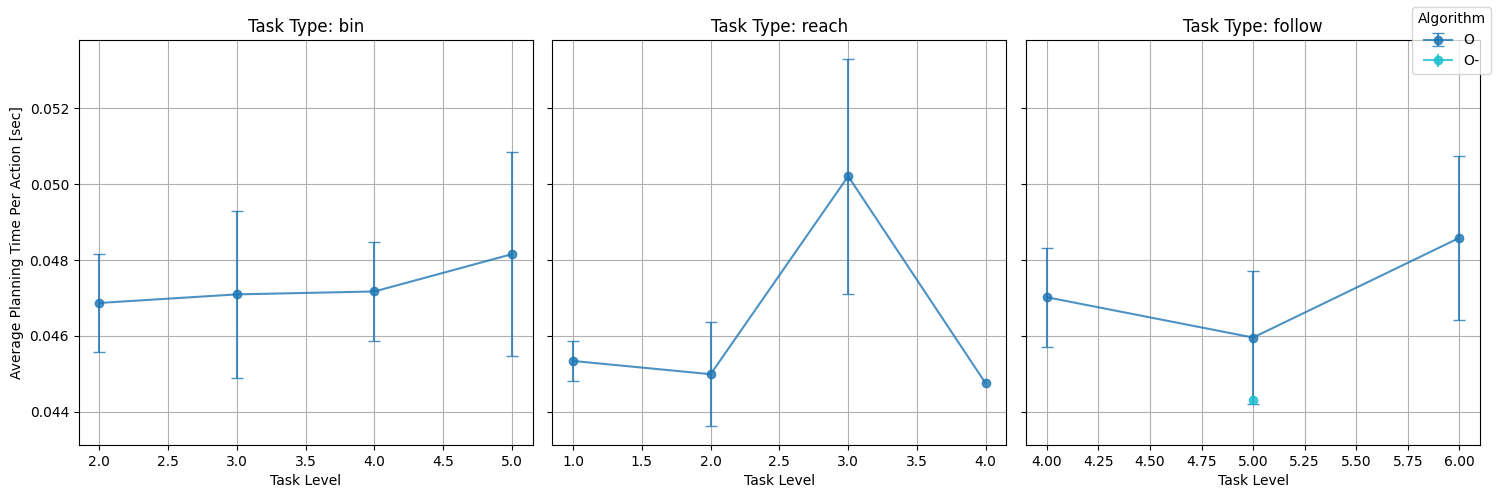

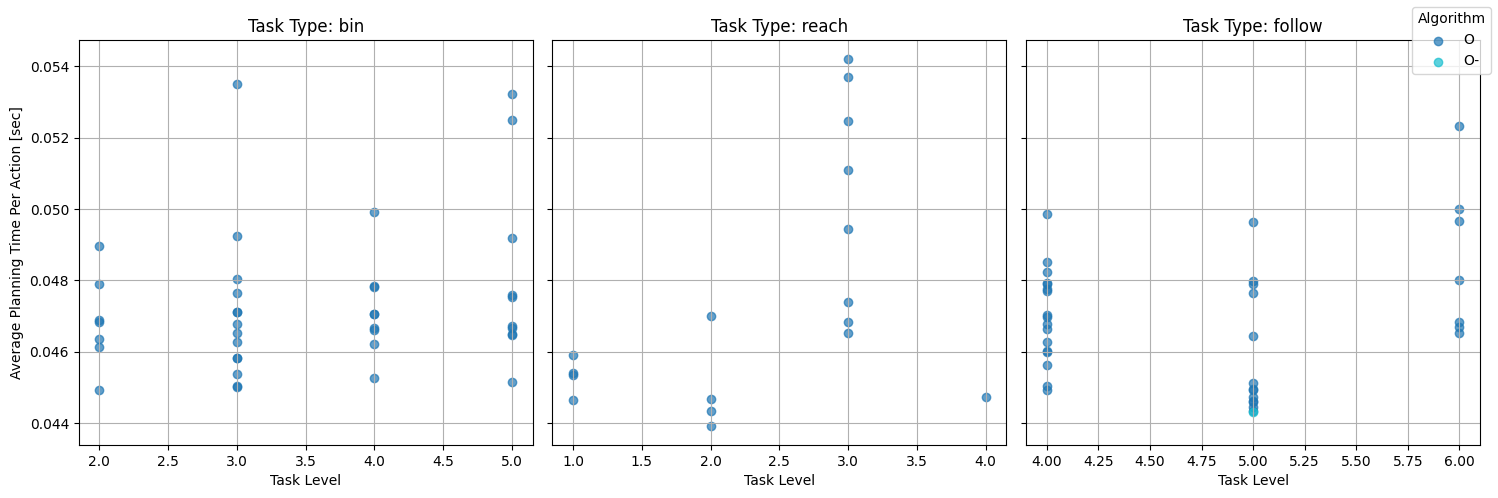

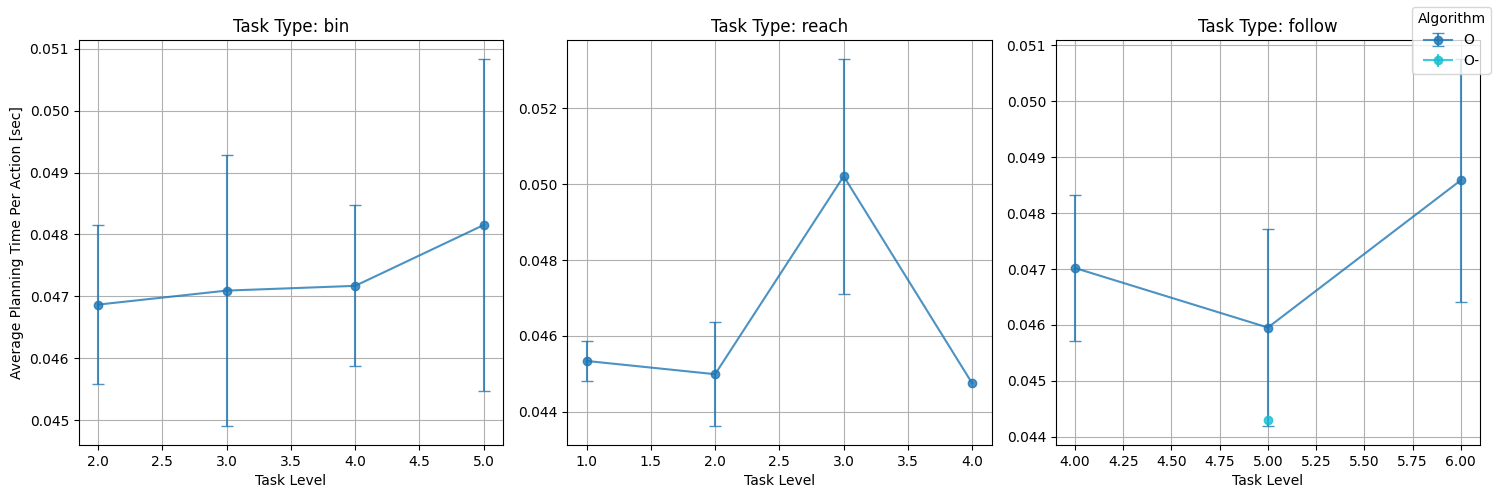

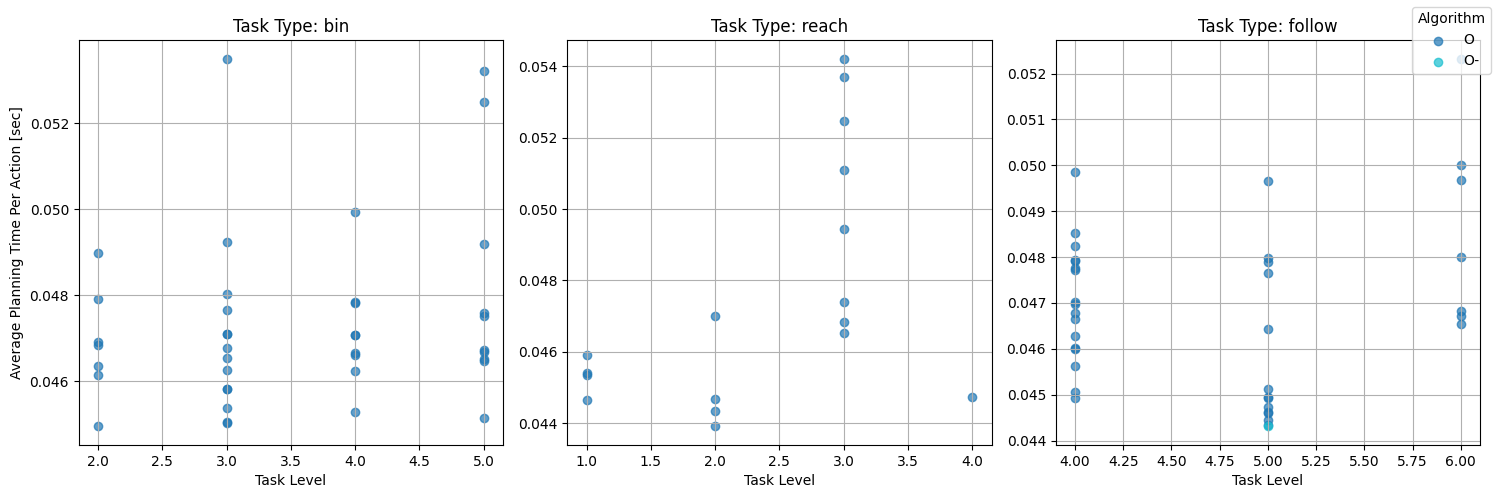

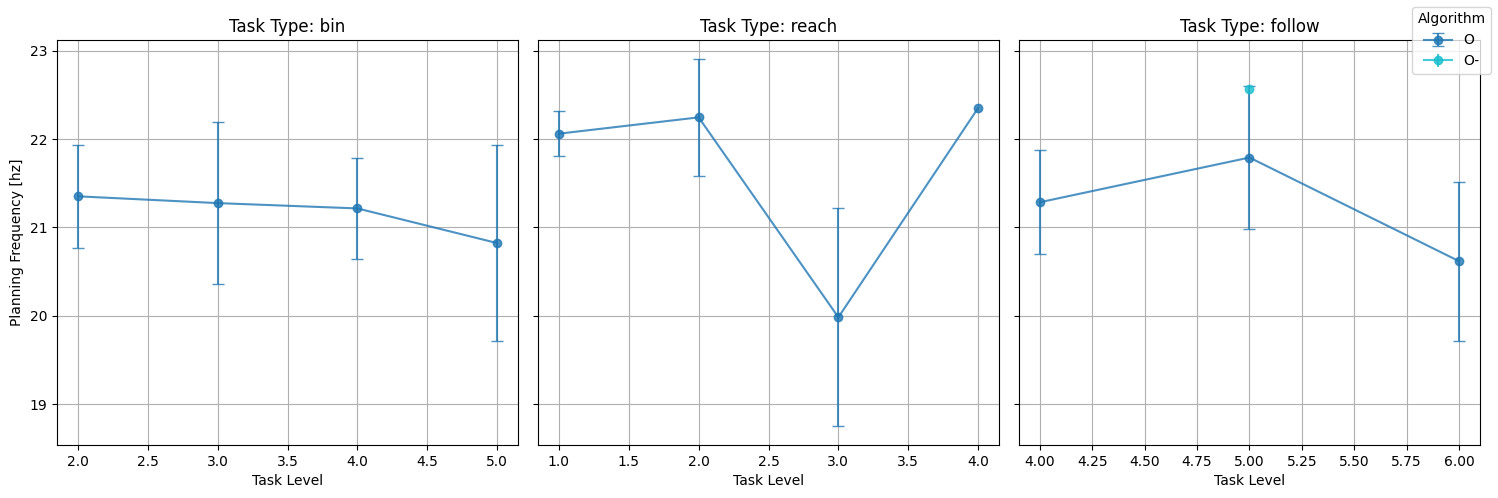

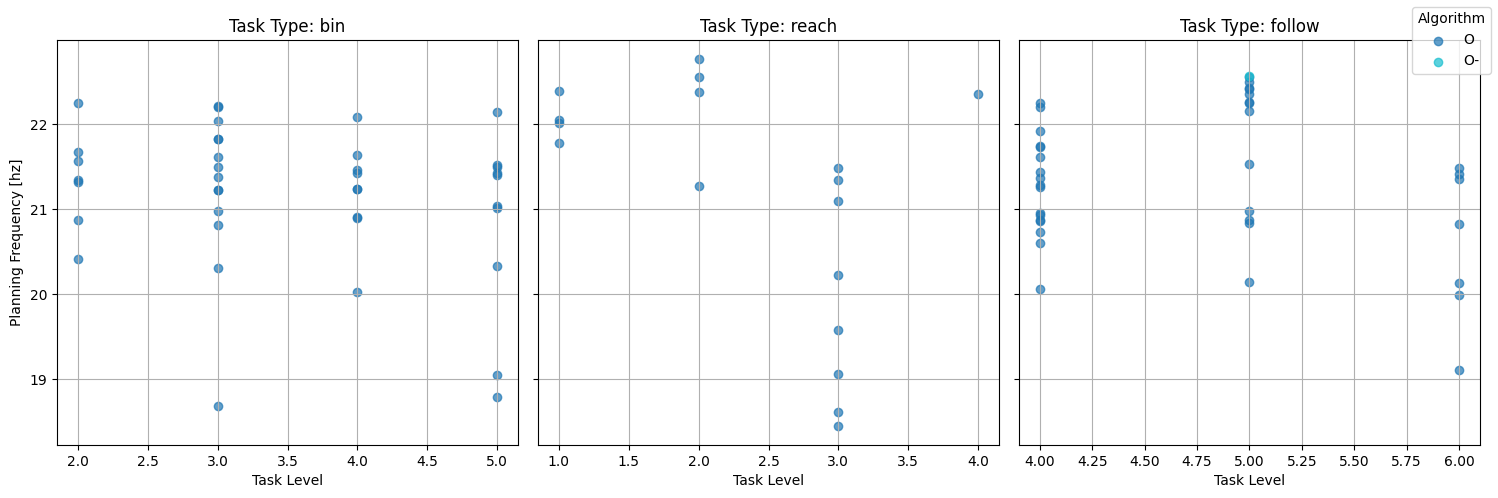

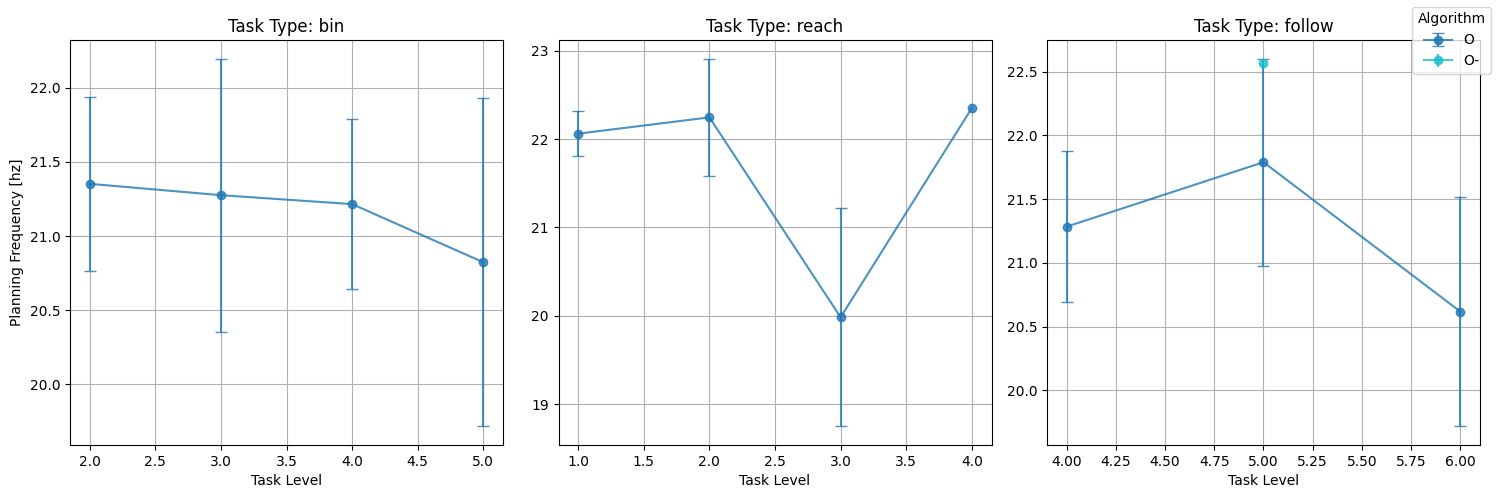

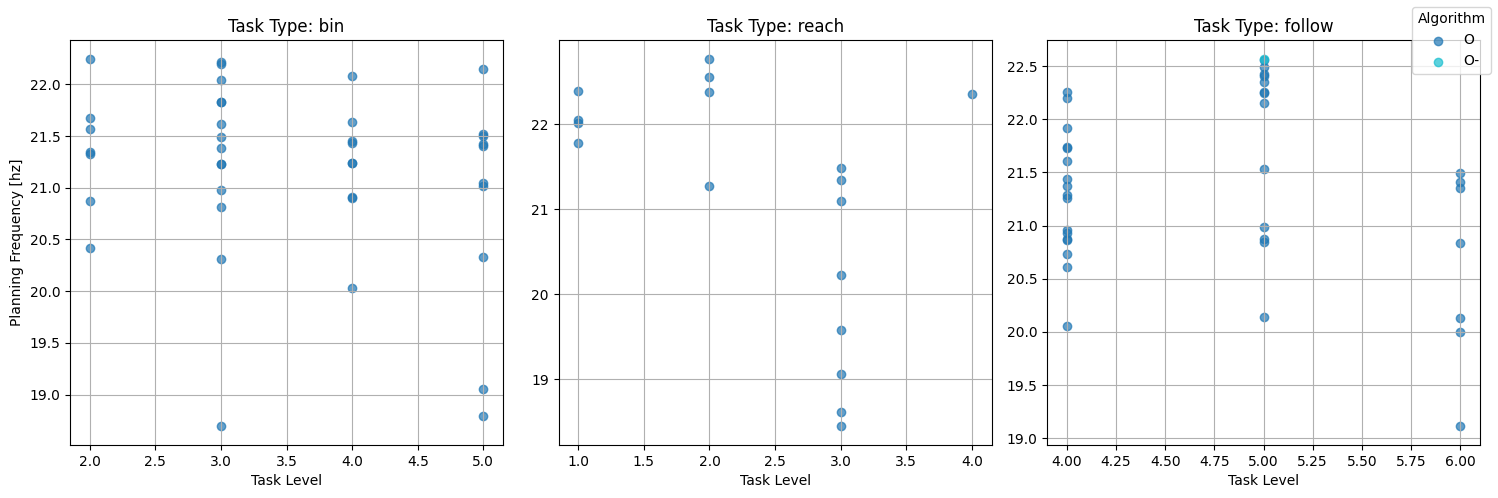

In [30]:

plot_type = ['Planning Time[sec]','Control Frequncy[hz]']
share_y = [True,False]
box_plot = [True,False]

for plot_type_i in plot_type:
    if plot_type_i == 'Planning Time[sec]':
        f = make_planning_time_plot
    
    elif plot_type_i == 'Control Frequncy[hz]':
        f = make_ctrl_freq_plot

    for share_y_i in share_y:
        for box_plot_i in box_plot:
            f(df_planning_time,boxplot=box_plot_i,sharey=share_y_i)
        
            
        

In [31]:

def plot_overall_distribution(df, target_label_name='Average Planning Time Per Action [sec]', target_col_name='tplanning_moaw', boxplot=False):
    df_plot = df.copy()

    algs = df_plot["alg"].unique()
    
    fig, ax = plt.subplots(figsize=(8, 6))

    # Assign colors to algorithms
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}

    if not boxplot:
        # Scatter plot for each algorithm
        for i, alg in enumerate(algs):
            sdf = df_plot[df_plot["alg"] == alg]
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[target_col_name],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
    else:
        # Boxplot
        data = [df_plot[df_plot["alg"] == alg][target_col_name] for alg in algs]
        ax.boxplot(
            data, labels=algs,
            patch_artist=True,
            boxprops=dict(facecolor="lightgray", alpha=0.5),
            medianprops=dict(color="red", linewidth=2)
        )
        # Color box outlines per algorithm
        for patch, alg in zip(ax.artists, algs):
            patch.set_facecolor(alg_color_map[alg])

    ax.set_xticks(range(1,len(algs)+1))
    ax.set_xticklabels(algs)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(target_label_name)
    ax.set_title("Distribution of " + target_label_name)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # Only add legend for scatter mode (boxplot already labeled by xticks)
    if not boxplot:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="Algorithm")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_910715/2380471027.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_910715/2380471027.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


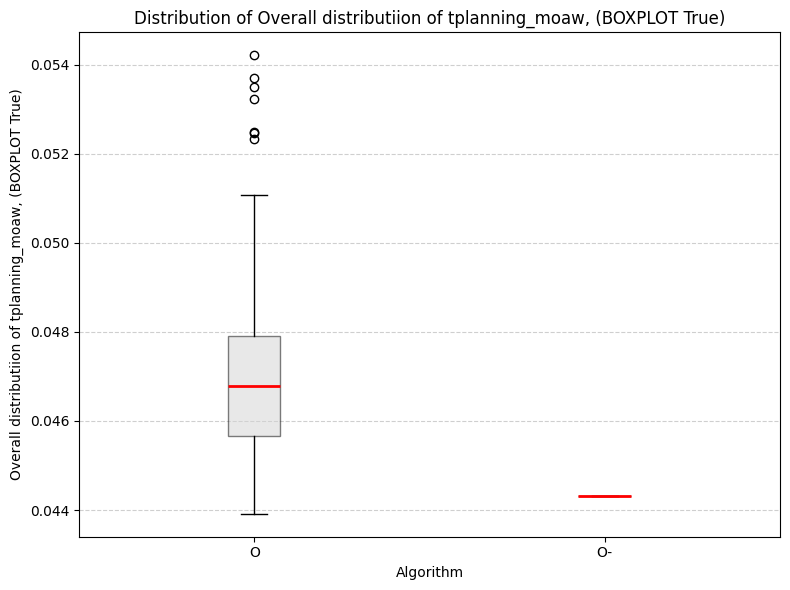

/tmp/ipykernel_910715/2380471027.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))


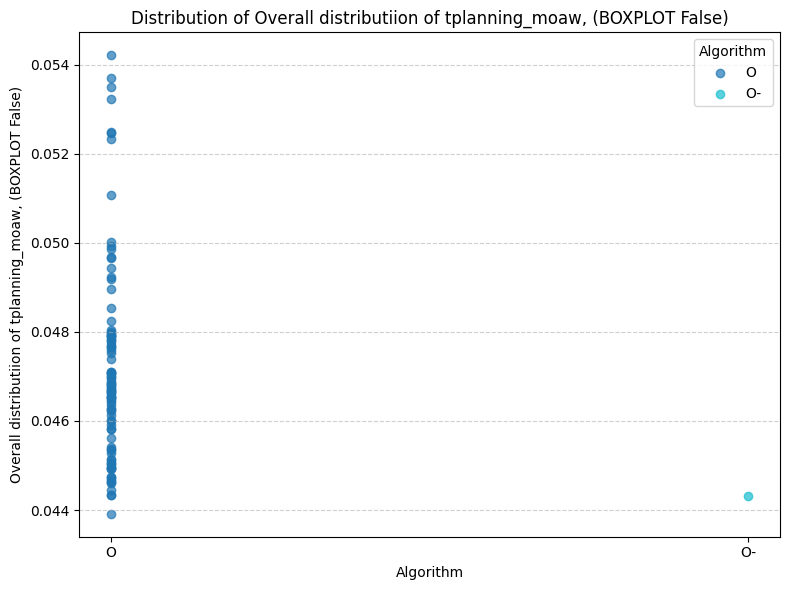

/tmp/ipykernel_910715/2380471027.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_910715/2380471027.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


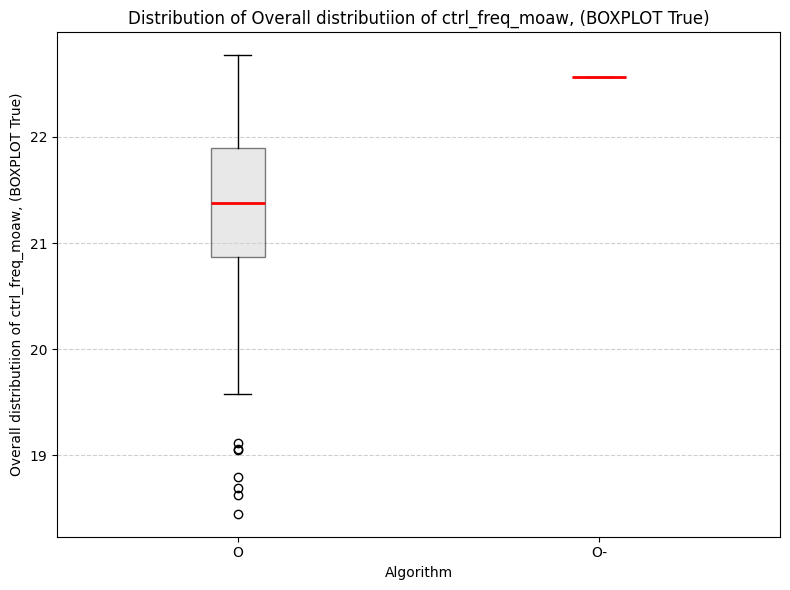

/tmp/ipykernel_910715/2380471027.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))


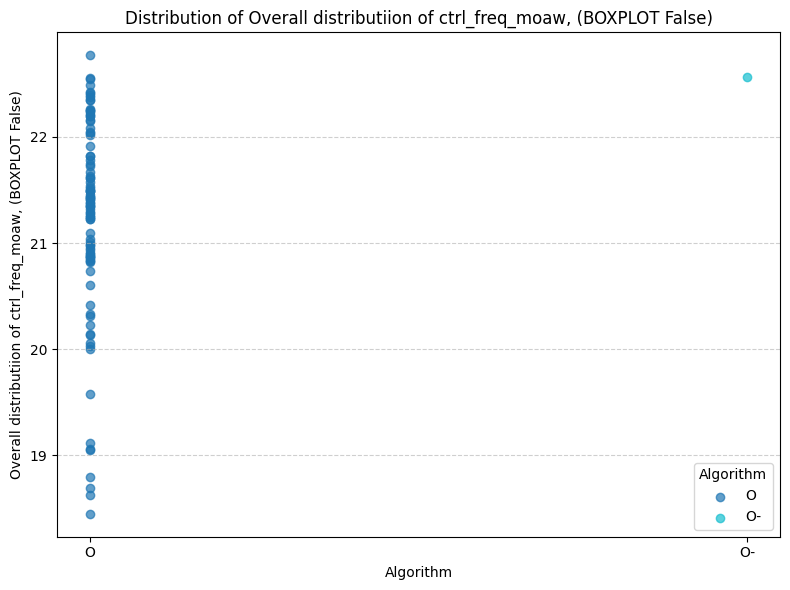

In [32]:
for target_col_name in ['tplanning_moaw','ctrl_freq_moaw']:
    for box_plot_i in box_plot:
        title = f'Overall distributiion of {target_col_name}, (BOXPLOT {box_plot_i})'   
        plot_overall_distribution(df_planning_time,title, target_col_name=target_col_name,boxplot=box_plot_i)

# Analyze tasks

## Make one df per task (3 in total) - each row indicates a unique simulation

### Count number of sims from each kind (before parsing, to check how many successful parsing processed we had)

In [33]:
print(f'Total bin sims: {len(bin_sims)}')
print(f'Total reach sims: {len(reach_sims)}')
print(f'Total follow sims: {len(follow_sims)}')


Total bin sims: 40
Total reach sims: 17
Total follow sims: 38


### Start the parsing (df making)

In [34]:
def analyze_tasks(all_sims,n_arm_max_for_follow=8):
    
    df_cols_shared = ['alg', 'task_level','task_seed', 'n_arms','wsteps_total','sim_id']

    
    task_specific_cols_bin = ['picked_total','placed_total']
    task_specific_cols_reach = ['reached_total','changed_total']
    
    task_specific_cols_follow = ['w_step'] + [f'arm_{k}_p_err' for k in range(n_arm_max_for_follow)] + [f'arm_{k}_q_err' for k in range(n_arm_max_for_follow)]
    bin_cols = df_cols_shared + task_specific_cols_bin
    bin_rows = []
    reach_cols = df_cols_shared + task_specific_cols_reach
    reach_rows = []
    follow_cols = df_cols_shared + task_specific_cols_follow
    df_follow = pd.DataFrame(columns=follow_cols)

    successfull_parsing_bin = []
    successfull_parsing_reach = []
    successfull_parsing_follow = []


    for i,sim in enumerate(all_sims):
        #if True:
        try:
            # for sim_idx, sim in enumerate(all_sims):
            task_df = sim.task_df
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            seed = sim.meta_data['task_seed']
            sim_id = sim.meta_data['timestamp']
            w_steps_total = task_df['w_step'].max()

            arm_col_names = [c for c in task_df.columns if c.startswith('arm_')]
            df_tmp = sim.task_df.copy()[['w_step',*arm_col_names]]
            
            row = [alg, task_level, seed, n_arms, w_steps_total, sim_id]
            if sim.meta_data['task_type'] == 'bin':            
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]
                if df_tmp_last_step.shape[0] > 1:
                    print(f'warning for sim:')
                    print(sim)
                    print(f'more than one row in df_tmp_last_step')
                    print(df_tmp_last_step)
                
                df_last_step = df_tmp_last_step.iloc[0] # take the first row from last step
                # for c in df_last_step:
                #     print(f'ssssd')
                #     print(type(c))
                #     tp_in = 'total_picks' in c
                #     print(f'{c} in total_picks: {tp_in}')
                total_picked_cols = []
                total_placed_cols = []
                for c in df_tmp_last_step.columns:
                    if 'total_picks' in str(c):
                        total_picked_cols.append(c)
                    if 'total_drops' in str(c):
                        total_placed_cols.append(c)
                # total_picked_cols = [c for c in df_tmp_last_step.columns if 'total_picks' in c] # for each arm
                # total_placed_cols = [c for c in df_tmp_last_step.columns if 'total_drops' in c] # for each arm
                print(df_last_step)
                if len(total_picked_cols) > 0:
                    total_picked_alg = df_last_step[total_picked_cols].sum()
                else:
                    continue
                if len(total_placed_cols) > 0:
                    total_placed_alg = df_last_step[total_placed_cols].sum()
                else:
                    continue

                row.extend([total_picked_alg, total_placed_alg])
                
                row_list = bin_rows
                success_list = successfull_parsing_bin
                
            elif sim.meta_data['task_type'] == 'reach':
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]                
                pd_series_last_step = df_tmp_last_step.iloc[0]
                sum_reached = 0
                sum_changed = 0
                for k in pd_series_last_step.keys():
                    if 'total_reached' in k:
                        sum_reached += pd_series_last_step[k]
                    elif 'total_changed' in k:
                        sum_changed += pd_series_last_step[k]
                row.extend([sum_reached, sum_changed])
                
                row_list = reach_rows
                success_list = successfull_parsing_reach
            
            elif sim.meta_data['task_type'] == 'follow':
                # task_specific_cols_follow = [f'arm_{k}_p_err' for k in range(n_arms)] + [f'arm_{k}_q_err' for k in range(n_arms)]                
                cur_follow_df = task_df[['w_step', *[c for c in task_df.columns if 'err' in c]]] # p,q err for each arm
                this_sim_follow_df = pd.DataFrame(columns=follow_cols)

                for k in range(n_arms):
                    p_err_col = f'arm_{k}_p_err'
                    q_err_col = f'arm_{k}_q_err'
                    cur_col_name = f'arm_{k}_err'
                    this_sim_follow_df[p_err_col] = cur_follow_df[cur_col_name].apply(lambda x: x[0])
                    this_sim_follow_df[q_err_col] = cur_follow_df[cur_col_name].apply(lambda x: x[1])
                    this_sim_follow_df['w_step'] = cur_follow_df['w_step']
                
                this_sim_follow_df['alg'] = alg
                this_sim_follow_df['task_level'] = task_level
                this_sim_follow_df['task_seed'] = seed
                this_sim_follow_df['n_arms'] = n_arms
                this_sim_follow_df['wsteps_total'] = w_steps_total
                this_sim_follow_df['sim_id'] = sim_id
                

                df_follow = pd.concat([df_follow, this_sim_follow_df])
                row_list = None
                success_list = successfull_parsing_follow
                
            else:
                raise ValueError(f'task type not supported: {sim.meta_data["task_type"]}')

            if row_list is not None:
                row_list.append(row)
            success_list.append(i)
        
        except Exception as e:
            print(f'error on sim:')
            print(sim)
            print(f'error: {e}')
            print('-'*100)
            continue

    df_bin = pd.DataFrame(bin_rows, columns=bin_cols)
    df_reach = pd.DataFrame(reach_rows, columns=reach_cols)
    # df_follow = pd.DataFrame(follow_rows, columns=follow_cols)

    return (df_bin,successfull_parsing_bin), (df_reach,successfull_parsing_reach), (df_follow,successfull_parsing_follow)

In [35]:
bin, reach, follow = analyze_tasks(all_sims)

/tmp/ipykernel_910715/1931679737.py:112: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_follow = pd.concat([df_follow, this_sim_follow_df])


w_step               500
arm_0_total_picks      3
arm_1_total_picks      3
arm_2_total_picks      3
arm_3_total_picks      3
arm_0_total_drops      2
arm_1_total_drops      2
arm_2_total_drops      2
arm_3_total_drops      3
Name: 1497, dtype: int64
w_step               500
arm_0_total_picks      3
arm_1_total_picks      2
arm_2_total_picks      3
arm_3_total_picks      2
arm_0_total_drops      3
arm_1_total_drops      4
arm_2_total_drops      1
arm_3_total_drops      0
Name: 1497, dtype: int64
w_step               500
arm_0_total_picks      2
arm_1_total_picks      2
arm_2_total_picks      3
arm_3_total_picks      1
arm_0_total_drops      3
arm_1_total_drops      1
arm_2_total_drops      1
arm_3_total_drops      1
Name: 1497, dtype: int64
w_step               500
arm_0_total_picks      3
arm_1_total_picks      3
arm_2_total_picks      3
arm_3_total_picks      3
arm_0_total_drops      2
arm_1_total_drops      3
arm_2_total_drops      3
arm_3_total_drops      2
Name: 1497, dtype: int64


### Final reasults of task-dfs making

In [36]:

df_bin, df_reach, df_follow = bin[0], reach[0], follow[0]
successfull_parsing_bin, successfull_parsing_reach, successfull_parsing_follow = bin[1], reach[1], follow[1]
print(f'In total: {len(successfull_parsing_bin)} bin tasks parsed successfully')
print(f'In total: {len(successfull_parsing_reach)} reach tasks parsed successfully')
print(f'In total: {len(successfull_parsing_follow)} follow tasks pardsed successfully')


In total: 40 bin tasks parsed successfully
In total: 17 reach tasks parsed successfully
In total: 38 follow tasks pardsed successfully


### Show snippets of tasks datasets

#### Bin task df legend
- wsteps_total: final world step in the simulation
- picked_total: sum of all items which have been picked in total (by the end of the simulation), over all arms.
- placed total- sum of all items which have been placed in total (by the end of the simulation), over all arms (must be <= picked total since placing occures only after picking) 


In [37]:
df_bin.tail()

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,picked_total,placed_total
35,O,3,1,4,500,2025-08-22_22:41:25,6,3
36,O,3,0,4,500,2025-08-21_15:03:22,10,6
37,O,2,4,4,500,2025-08-22_20:55:24,12,10
38,O,3,1,4,500,2025-08-22_22:29:47,6,3
39,O,3,3,4,500,2025-08-23_00:51:40,11,9


#### Follow task df legend
- w_step: current step number in the simulation (world step)
- wsteps_total: final world step in the simulation
- arm_%i%_p_err: position error between end effector of arm i to the target of arm i (in meters, norm over x,y,z axis). 
- arm_%i%_q_err: oreientation mean orientation error in degrees, over the 3 rotation axis (roll, pitch, yaw) between the end effector of arm i to the target of arm i  

In [38]:
df_follow.tail()

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,w_step,arm_0_p_err,arm_1_p_err,arm_2_p_err,...,arm_6_p_err,arm_7_p_err,arm_0_q_err,arm_1_q_err,arm_2_q_err,arm_3_q_err,arm_4_q_err,arm_5_q_err,arm_6_q_err,arm_7_q_err
495,O,5,0,4,500,2025-08-23_14:13:01,496,0.848776,0.222522,0.055251,...,NaN,NaN,69.422194,57.863707,166.902191,182.397601,NaN,NaN,NaN,NaN
496,O,5,0,4,500,2025-08-23_14:13:01,497,0.848105,0.214668,0.050647,...,NaN,NaN,69.200695,56.821359,167.261010,181.318872,NaN,NaN,NaN,NaN
497,O,5,0,4,500,2025-08-23_14:13:01,498,0.857710,0.220103,0.058154,...,NaN,NaN,69.200695,56.821359,167.261010,181.318872,NaN,NaN,NaN,NaN
498,O,5,0,4,500,2025-08-23_14:13:01,499,0.857698,0.212566,0.052139,...,NaN,NaN,68.860703,56.009578,167.474081,180.049838,NaN,NaN,NaN,NaN
499,O,5,0,4,500,2025-08-23_14:13:01,500,0.867463,0.217898,0.059730,...,NaN,NaN,68.860703,56.009578,167.474081,180.049838,NaN,NaN,NaN,NaN


#### Reach task df legend

- changed_total: Num of allocated targets in total (sum over all arms)
- reached_total: Num of targets arms reached (sum over all arms)


In [39]:
df_reach.tail()

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,reached_total,changed_total
12,O,3,0,4,500,2025-08-21_22:32:33,41,43
13,O,2,2,4,500,2025-08-24_04:26:38,46,46
14,O,3,0,4,500,2025-08-24_08:11:16,29,34
15,O,3,3,4,500,2025-08-24_09:13:26,25,31
16,O,4,1,4,500,2025-08-24_11:10:36,11,22


## Analyze follow

In [40]:
df_follow.head()
p_err_cols = [c for c in df_follow.columns if 'p_err' in c]
df_follow['p_err_mean'] = df_follow[p_err_cols].mean(axis=1)
p_err_var = df_follow[p_err_cols].var(axis=1)
df_follow['p_err_var'] = p_err_var

q_err_cols = [c for c in df_follow.columns if 'q_err' in c]
df_follow['q_err_mean'] = df_follow[q_err_cols].mean(axis=1)
q_err_var = df_follow[q_err_cols].var(axis=1)
df_follow['q_err_var'] = q_err_var

df_follow.head()

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,w_step,arm_0_p_err,arm_1_p_err,arm_2_p_err,...,arm_2_q_err,arm_3_q_err,arm_4_q_err,arm_5_q_err,arm_6_q_err,arm_7_q_err,p_err_mean,p_err_var,q_err_mean,q_err_var
0,O,4,2,4,500,2025-08-23_12:26:52,1,0.344752,0.344752,0.344752,...,90.097558,90.097568,NaN,NaN,NaN,NaN,0.344752,0.0,90.220106,0.020022
1,O,4,2,4,500,2025-08-23_12:26:52,2,0.344910,0.344765,0.344803,...,90.097558,90.097568,NaN,NaN,NaN,NaN,0.34479,0.0,90.220106,0.020022
2,O,4,2,4,500,2025-08-23_12:26:52,3,0.337865,0.337719,0.337757,...,89.190539,89.062550,NaN,NaN,NaN,NaN,0.337501,0.0,90.215147,1.582803
3,O,4,2,4,500,2025-08-23_12:26:52,4,0.337998,0.337608,0.337795,...,89.190539,89.062550,NaN,NaN,NaN,NaN,0.337456,0.0,90.215147,1.582803
4,O,4,2,4,500,2025-08-23_12:26:52,5,0.318717,0.318680,0.320139,...,88.524818,88.759847,NaN,NaN,NaN,NaN,0.318974,0.000001,90.645047,5.357026


In [41]:
# df_follow = df_follow[df_follow['sim_id'] == '2025-08-18_16:52:51']
# x = df_follow['w_step']
# y = df_follow['p_err_mean']

# # Create subplots, one per task_type
# algs = df_follow['alg'].unique()
# fig, axes = plt.subplots(1, len(algs), figsize=(15, 5), sharey=True) # one row, n columns (n = number of task types)
# # In case task_types is just one value
# if len(algs) == 1:
#     axes = [axes]

# for alg, ax in zip(algs, axes):
#     sdf = df_follow[df_follow['alg'] == alg]
#     ax.scatter(sdf['w_step'], sdf['arm_3_p_err'])
#     ax.set_title(f'{task_type}')





# plt.show()


# Analze bin

In [42]:
df_bin

,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,picked_total,placed_total
0,O,5,3,4,500,2025-08-23_09:08:15,12,9
1,O,2,2,4,500,2025-08-22_19:05:27,10,8
2,O,2,0,4,500,2025-08-22_18:32:41,8,6
3,O,3,1,4,500,2025-08-21_17:19:41,12,10
4,O,2,0,4,500,2025-08-21_11:41:07,8,6
5,O,3,2,4,500,2025-08-22_23:34:43,10,7
6,O,5,0,4,500,2025-08-21_19:12:43,8,6
7,O,4,0,4,500,2025-08-21_18:15:14,8,6
8,O,3,4,4,500,2025-08-23_01:02:30,12,10
9,O,4,1,4,500,2025-08-23_03:19:39,10,8


## Bin sanity check

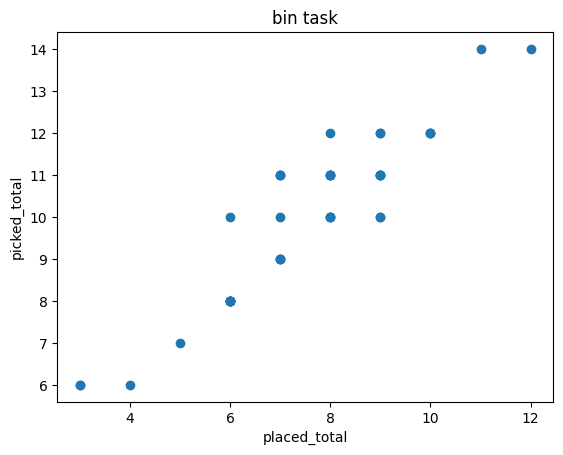

In [43]:
# sanity check
df_bin_sanity = df_bin.copy()
# df_bin.plot()
# df_bin = # df_bin[['picked_total','placed_total','alg','task_level']]
y = df_bin_sanity['picked_total'].values
x = df_bin_sanity['placed_total'].values
plt.scatter(x,y)
plt.xlabel('placed_total')
plt.ylabel('picked_total')
plt.title('bin task')
plt.show()

/tmp/ipykernel_910715/3006845986.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_910715/3006845986.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


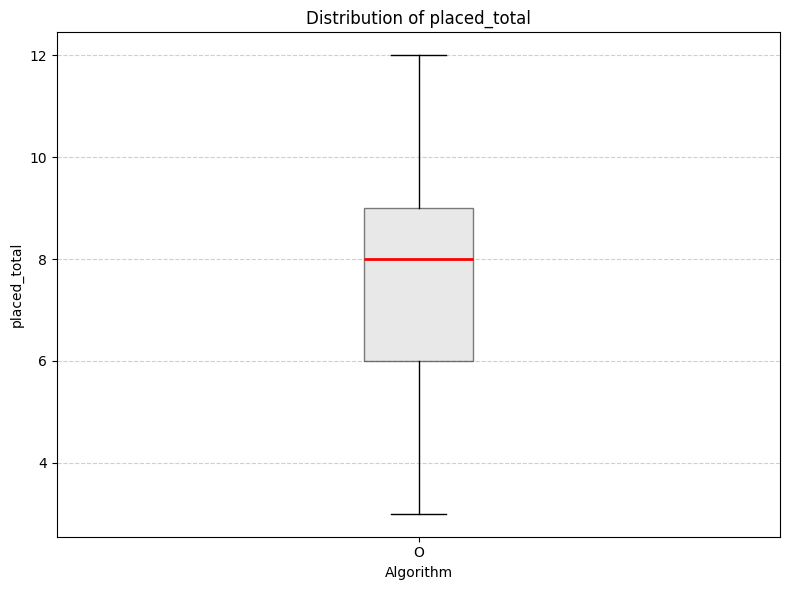

In [44]:
# df_bin_algs = df_bin.groupby('alg')
#df_bin_algs.plot()
def compare_algs_in_bin_task(df,share_y=True,y='placed_total',boxplot=True):
    df_plot = df.copy()
    algs = df_plot["alg"].unique()
    target_col_name = y
    fig, ax = plt.subplots(figsize=(8, 6))

    # Assign colors to algorithms
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}

    if not boxplot:
        for i, alg in enumerate(algs):
            sdf = df_plot[df_plot["alg"] == alg]
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[target_col_name],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
    else:
        # Boxplot
        data = [df_plot[df_plot["alg"] == alg][target_col_name] for alg in algs]
        ax.boxplot(
            data, labels=algs,
            patch_artist=True,
            boxprops=dict(facecolor="lightgray", alpha=0.5),
            medianprops=dict(color="red", linewidth=2), # median line in red,
            showfliers=True # show outliers (points outside the whiskers)
        )
        # Color box outlines per algorithm
        for patch, alg in zip(ax.artists, algs):
            patch.set_facecolor(alg_color_map[alg])

    ax.set_xticks(range(1,len(algs)+1))
    ax.set_xticklabels(algs)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(y)
    ax.set_title("Distribution of " + y)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    if not boxplot:
        # Only add legend for scatter mode (boxplot already labeled by xticks)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="Algorithm")

    plt.tight_layout()
    plt.show()

compare_algs_in_bin_task(df_bin)

# Analyze Safety

In [45]:

all_sims = bin_sims + reach_sims + follow_sims

def check_rrc_rre_for_agent(df):
    
    w_steps_in_rrc = set()
    w_steps_in_rre = set()
    agent_world_col_world_steps = df[df.env_cols == True]['w_step']
    agent_arm_col_world_steps = df[df.arm_cols == True]['w_step']

    for w_step in agent_world_col_world_steps:
        w_steps_in_rrc.add(w_step)
    for w_step in agent_arm_col_world_steps:
        w_steps_in_rre.add(w_step)

    return w_steps_in_rrc, w_steps_in_rre

columns = ['alg', 'n_arms', 'wstep_total', 'task_type', 'task_level', 'rre_n','rrc_n', 'rrc_chance', 'rre_chance', 'task_seed','sim_id']
rows = []
successfull_parsing = []
unsuccessfull_parsing = []
for sim in reach_sims+bin_sims+follow_sims:
    try:
        centralized = sim.is_centralized()
        w_steps_in_rrc = set()
        w_steps_in_rre = set()
        agents_dfs = sim.get_agents_dfs()
        if centralized:
            df = sim.get_agents_dfs()[0]
            n_steps = df.w_step.max()
            rre_n, rrc_n = check_rrc_rre_for_agent(df)
        else:
            # list of dfs one for each agent (arm)
            n_steps = 0    
            for df in agents_dfs:
                rre_n, rrc_n = check_rrc_rre_for_agent(df)
                w_steps_in_rrc = set.union(w_steps_in_rrc, rrc_n)
                w_steps_in_rre = set.union(w_steps_in_rre, rre_n)
                n_steps = max(n_steps, df.w_step.max())
            
        rre_n = len(w_steps_in_rre)
        rrc_n = len(w_steps_in_rrc)
        rre_chance = rre_n / n_steps
        rrc_chance = rrc_n / n_steps
        rows.append([sim.meta_data['alg'], sim.meta_data['n_arms'], n_steps, sim.meta_data['task_type'],sim.meta_data['task_level'], rre_n, rrc_n, rrc_chance, rre_chance,sim.meta_data['task_seed'], sim.meta_data['timestamp']])
        successfull_parsing.append(sim)
        print(sim.meta_data['timestamp'])
        print(sim.meta_data['task_seed'])


    except Exception as e:
        unsuccessfull_parsing.append((sim,e))

parsing_summary(successfull_parsing, unsuccessfull_parsing)

df_collisions = pd.DataFrame(rows, columns=columns)
df_collisions



2025-08-24_11:03:30
3
2025-08-23_23:53:59
0
2025-08-24_06:03:53
2
2025-08-23_22:36:27
0
2025-08-24_03:49:43
2
2025-08-24_09:57:05
4
2025-08-23_23:57:18
2
2025-08-24_06:32:07
0
2025-08-24_08:15:01
1
2025-08-24_11:33:49
4
2025-08-24_02:00:02
3
2025-08-24_04:11:43
3
2025-08-21_22:32:33
0
2025-08-24_04:26:38
2
2025-08-24_08:11:16
0
2025-08-24_09:13:26
3
2025-08-24_11:10:36
1
2025-08-23_09:08:15
3
2025-08-22_19:05:27
2
2025-08-22_18:32:41
0
2025-08-21_17:19:41
1
2025-08-21_11:41:07
0
2025-08-22_23:34:43
2
2025-08-21_19:12:43
0
2025-08-21_18:15:14
0
2025-08-23_01:02:30
4
2025-08-23_03:19:39
1
2025-08-23_00:52:58
3
2025-08-23_05:14:00
4
2025-08-23_07:58:41
3
2025-08-23_08:35:56
3
2025-08-23_08:34:09
2
2025-08-22_18:42:41
1
2025-08-21_13:30:20
0
2025-08-22_19:03:16
1
2025-08-23_09:52:20
4
2025-08-22_21:50:48
4
2025-08-23_03:30:46
1
2025-08-21_15:22:42
1
2025-08-23_09:11:57
3
2025-08-22_21:35:02
0
2025-08-22_22:51:35
1
2025-08-23_00:21:25
3
2025-08-23_04:24:23
2
2025-08-23_00:50:26
3
2025-08-23

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,sim_id
0,O,4,500,reach,3,148,217,0.434,0.296,3,2025-08-24_11:03:30
1,O,4,500,reach,1,0,0,0.000,0.000,0,2025-08-23_23:53:59
2,O,4,500,reach,2,0,0,0.000,0.000,2,2025-08-24_06:03:53
3,O,4,500,reach,1,0,0,0.000,0.000,0,2025-08-23_22:36:27
4,O,4,500,reach,2,0,0,0.000,0.000,2,2025-08-24_03:49:43
...,...,...,...,...,...,...,...,...,...,...,...
90,O,4,500,follow,4,0,0,0.000,0.000,3,2025-08-23_13:33:42
91,O,4,500,follow,4,0,0,0.000,0.000,2,2025-08-21_22:01:04
92,O,4,500,follow,4,0,0,0.000,0.000,3,2025-08-23_12:26:55
93,O,4,500,follow,4,0,0,0.000,0.000,1,2025-08-23_11:30:39


In [46]:
df_collisions.describe()

,n_arms,wstep_total,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed
count,95.0,95.0,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,4.0,500.0,3.810526,5.905263,18.400000,0.036800,0.011811,1.652632
std,0.0,0.0,1.265708,20.812268,57.582392,0.115165,0.041625,1.374296
min,4.0,500.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.0,500.0,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.0,500.0,4.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,4.0,500.0,5.000000,0.000000,3.000000,0.006000,0.000000,3.000000
max,4.0,500.0,6.000000,148.000000,346.000000,0.692000,0.296000,4.000000


In [47]:
def compare_algs_safety(df_collisions,share_y=True,boxplot=False,chance=True):
    df_plot = df_collisions.copy()
    algs = df_plot["alg"].unique()
    
    
    if chance:
        y1 = 'rrc_chance'
        y2 = 'rre_chance'
    else:
        y1 = 'rrc_n'
        y2 = 'rre_n'
        
    fig, ax = plt.subplots(figsize=(8, 6))

    # Assign colors to algorithms
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}

    if not boxplot:
        for i, alg in enumerate(algs):
            sdf = df_plot[df_plot["alg"] == alg]
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[y1],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[y2],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
    else:
        # Boxplot
        data = [df_plot[df_plot["alg"] == alg][[y1,y2]] for alg in algs]
        data1 = [df_plot[df_plot["alg"] == alg][y1] for alg in algs]
        data2 = [df_plot[df_plot["alg"] == alg][y2] for alg in algs]
        ax.boxplot(
            data1, 
            labels=algs,
            patch_artist=True,
            boxprops=dict(facecolor="lightgray", alpha=0.5),
            medianprops=dict(color="red", linewidth=2), # median line in red,
            showfliers=True # show outliers (points outside the whiskers)
        )
        # Color box outlines per algorithm
        for patch, alg in zip(ax.artists, algs):
            patch.set_facecolor(alg_color_map[alg])


    ax.set_xticks(range(1,len(algs)+1))
    ax.set_xticklabels(algs)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(y)
    # ax.set_title("Distribution of " + y)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    if not boxplot:
        # Only add legend for scatter mode (boxplot already labeled by xticks)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="Algorithm")

    plt.tight_layout()
    plt.show()

if not O_tuning:
    compare_algs_safety(df_collisions)


### If in tuning mode, make a unified dataset (this is for debug)

/tmp/ipykernel_910715/65109495.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.15' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_tuning.loc[df_tuning['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']


Index(['alg', 'n_arms', 'wstep_total', 'task_type', 'task_level', 'rre_n',
       'rrc_n', 'rrc_chance', 'rre_chance', 'task_seed', 'sim_id', 'weight',
       'trust', 'cov', 'changed_total', 'reached_total', 'picked_total',
       'placed_total', 'p_err_mean_arms_wsteps', 'p_err_var_arms_wsteps'],
      dtype='object')


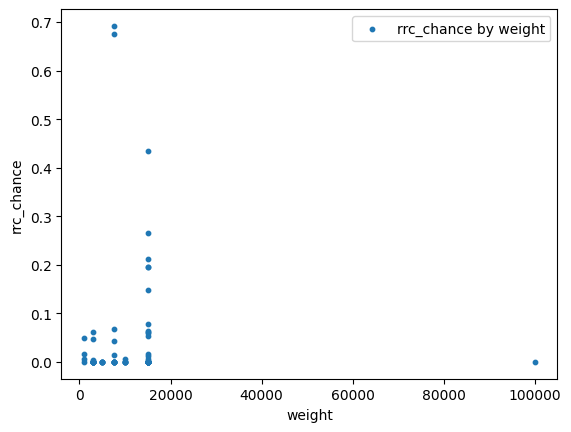

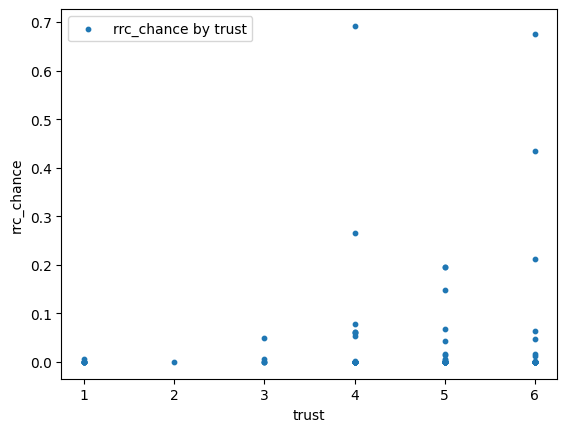

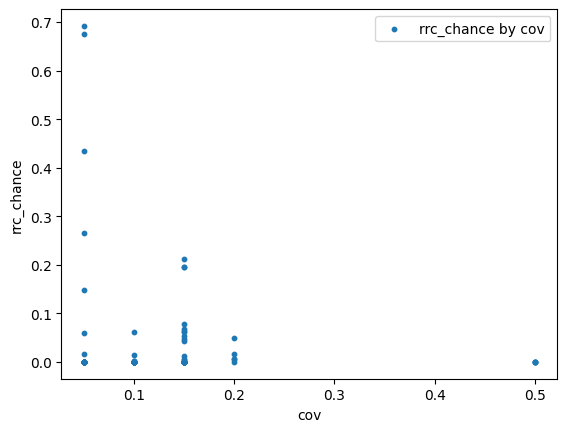

In [48]:
def make_df_tuning(df_collisions,successfull_parsing,root_path):
    import yaml
    df_tuning = df_collisions.copy()
    df_tuning[['weight','trust','cov']] = -1,-1,-1 # add columns for tuning
    all_sims = os.listdir(root_path)
    for sim in successfull_parsing:
        sim_id = sim.meta_data['timestamp']
        for dirname in all_sims:
            if sim_id in dirname:
                with open(os.path.join(root_path, dirname, 'particle_cfg.yml'), 'r') as f:
                    particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                    df_tuning.loc[df_tuning['sim_id'] == sim_id, 'weight'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['weight']
                    df_tuning.loc[df_tuning['sim_id'] == sim_id, 'trust'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']
                    df_tuning.loc[df_tuning['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']
                    df_tuning.loc[df_tuning['sim_id'] == sim_id, 'alg'] = sim.meta_data['alg']
                    df_tuning.loc[df_tuning['sim_id'] == sim_id, 'task_type'] = sim.meta_data['task_type']
                    df_tuning.loc[df_tuning['sim_id'] == sim_id, 'task_level'] = sim.meta_data['task_level']
                    df_tuning.loc[df_tuning['sim_id'] == sim_id, 'task_seed'] = sim.meta_data['task_seed']
                    if sim.meta_data['task_type'] == 'reach':
                        df_tuning.loc[df_tuning['sim_id'] == sim_id, 'changed_total'] = df_reach[df_reach['sim_id'] == sim_id]['changed_total']
                        df_tuning.loc[df_tuning['sim_id'] == sim_id, 'reached_total'] = df_reach[df_reach['sim_id'] == sim_id]['reached_total']
                    elif sim.meta_data['task_type'] == 'follow':
                        df_tuning.loc[df_tuning['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = df_follow[df_follow['sim_id'] == sim_id]['p_err_mean'].mean() # taking the mean over arms and making a mean over w_steps
                        df_tuning.loc[df_tuning['sim_id'] == sim_id, 'p_err_var_arms_wsteps'] = df_follow[df_follow['sim_id'] == sim_id]['p_err_var'].mean() # taking the var over arms and making a mean over w_steps
                        
                    elif sim.meta_data['task_type'] == 'bin':
                        df_tuning.loc[df_tuning['sim_id'] == sim_id, 'picked_total'] = df_bin[df_bin['sim_id'] == sim_id]['picked_total'].values[0]
                        df_tuning.loc[df_tuning['sim_id'] == sim_id, 'placed_total'] = df_bin[df_bin['sim_id'] == sim_id]['placed_total'].values[0]
                        

                    else:
                        raise ValueError(f'Task type {sim.meta_data["task_type"]} not supported')

    return df_tuning

if O_tuning:
    df_tuning = make_df_tuning(df_collisions,successfull_parsing,root_path)
    print(df_tuning.columns)
    df_tuning.plot.scatter(x='weight',y='rrc_chance',label='rrc_chance by weight',s=10)
    plt.show()
    df_tuning.plot.scatter(x='trust',y='rrc_chance',label='rrc_chance by trust',s=10)
    plt.show()
    df_tuning.plot.scatter(x='cov',y='rrc_chance',label='rrc_chance by cov',s=10)
    plt.show()
    df_tuning_gb = df_tuning.groupby(['cov', 'weight', 'trust'])
    df_tuning_gb_agg = df_tuning_gb.agg({'rrc_chance': 'mean', 'rre_chance': 'mean'}).reset_index()
    
    
    reach_task_specific_cols = ['reached_total','changed_total']
    follow_task_specific_cols = ['p_err_mean_arms_wsteps','p_err_var_arms_wsteps']
    bin_task_specific_cols = ['picked_total','placed_total']
    
    df_tuning_bin = df_tuning[df_tuning['task_type'] == 'bin'].copy()
    df_tuning_bin.drop(columns=reach_task_specific_cols+follow_task_specific_cols,inplace=True)
    
    df_tuning_reach = df_tuning[df_tuning['task_type'] == 'reach'].copy()
    df_tuning_reach.drop(columns=bin_task_specific_cols+follow_task_specific_cols,inplace=True)
    
    df_tuning_follow = df_tuning[df_tuning['task_type'] == 'follow'].copy()
    df_tuning_follow.drop(columns=bin_task_specific_cols+reach_task_specific_cols,inplace=True)


else:
    df_tuning = None
    df_tuning_bin = None
    df_tuning_reach = None
    df_tuning_follow = None

In [49]:
df_bin



,alg,task_level,task_seed,n_arms,wsteps_total,sim_id,picked_total,placed_total
0,O,5,3,4,500,2025-08-23_09:08:15,12,9
1,O,2,2,4,500,2025-08-22_19:05:27,10,8
2,O,2,0,4,500,2025-08-22_18:32:41,8,6
3,O,3,1,4,500,2025-08-21_17:19:41,12,10
4,O,2,0,4,500,2025-08-21_11:41:07,8,6
5,O,3,2,4,500,2025-08-22_23:34:43,10,7
6,O,5,0,4,500,2025-08-21_19:12:43,8,6
7,O,4,0,4,500,2025-08-21_18:15:14,8,6
8,O,3,4,4,500,2025-08-23_01:02:30,12,10
9,O,4,1,4,500,2025-08-23_03:19:39,10,8


In [50]:
tuned_params = ['weight','trust','cov']
success_metrics = {'bin':['placed_total'],'reach':['reached_total'],'follow':['p_err_mean_arms_wsteps']}
tuning_task_dfs = {'bin':df_tuning_bin,'reach':df_tuning_reach,'follow':df_tuning_follow}


for i,param in enumerate(tuned_params):
    print('-'*100)
    print(f'Param: {param}  {i+1}/{len(tuned_params)}')
    print('-'*100)
    for task_type, cols in success_metrics.items():
        df_task_specific = tuning_task_dfs[task_type]
        print(f'Task: {task_type},metric: {success_metrics[task_type][0]}, \n{df_task_specific.groupby(param)[success_metrics[task_type]].mean()}')

    for safety_metric in ['rrc_chance','rre_chance']:
        for task_type, cols in success_metrics.items():
            df_task_specific = tuning_task_dfs[task_type]
            print(f'Safety metric: {safety_metric}, \n{df_task_specific.groupby(param)[safety_metric].mean()}')





----------------------------------------------------------------------------------------------------
Param: weight  1/3
----------------------------------------------------------------------------------------------------
Task: bin,metric: placed_total, 
        placed_total
weight              
1000        7.750000
3000        8.400000
5000        7.000000
7500        6.800000
10000       6.000000
15000       7.681818
Task: reach,metric: reached_total, 
        reached_total
weight               
3000        38.000000
5000        41.000000
15000       33.214286
Task: follow,metric: p_err_mean_arms_wsteps, 
        p_err_mean_arms_wsteps
weight                        
3000                  0.072806
5000                  0.104202
7500                  0.084087
10000                 0.079160
15000                 0.072911
100000                0.056437
Safety metric: rrc_chance, 
weight
1000     0.018000
3000     0.023200
5000     0.000000
7500     0.298800
10000    0.002000
15000    0.04

In [51]:
def heatmap_tuning_stats_3d(df_tuning, color_column='rrc_chance',color_column_min=None,
color_column_max=None,aggregation=False):

    if color_column_min is not None:
        print(f'filtering {color_column} >= {color_column_min}')
        print(f'num of rows before filtering: {len(df_tuning)}')
        df_tuning = df_tuning[df_tuning[color_column] >= color_column_min]
        print(f'{color_column} min: {df_tuning[color_column].min()}')
        print(f'num of rows after filtering: {len(df_tuning)}')
        # black = color_column_min
    if color_column_max is not None:
        print(f'filtering {color_column} <= {color_column_max}')
        print(f'num of rows before filtering: {len(df_tuning)}')
        df_tuning = df_tuning[df_tuning[color_column] <= color_column_max]
        print(f'{color_column} max: {df_tuning[color_column].max()}')
        print(f'num of rows after filtering: {len(df_tuning)}')
        #white = color_column_max

    df_tuning_gb = df_tuning.groupby(['cov', 'weight', 'trust']) # x,y,z axis columns
    if aggregation:
        df_tuning_gb_agg = df_tuning_gb.agg({color_column: 'mean'}).reset_index()
        color_column = 'rrc_chance'
    else:
        df_tuning_gb_agg = df_tuning
            

    point_size = 100
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection='3d', elev=20, azim=30)
    scatter = ax.scatter(df_tuning_gb_agg['cov'], df_tuning_gb_agg['weight'], df_tuning_gb_agg['trust'], 
               c=df_tuning_gb_agg[color_column], cmap='hot', linewidth=1, alpha=0.8,s=10)
    ax.set_xlabel('cov')
    ax.set_ylabel('weight')
    ax.set_zlabel('trust')

    title = f'{color_column} stats in 3D For tuning!'
    plt.title(title)
    plt.colorbar(scatter, label=color_column)
    plt.tight_layout()
    plt.show()



filtering rrc_chance >= 0.1
num of rows before filtering: 95
rrc_chance min: 0.148
num of rows after filtering: 8
filtering rrc_chance <= 0.01
num of rows before filtering: 8
rrc_chance max: nan
num of rows after filtering: 0


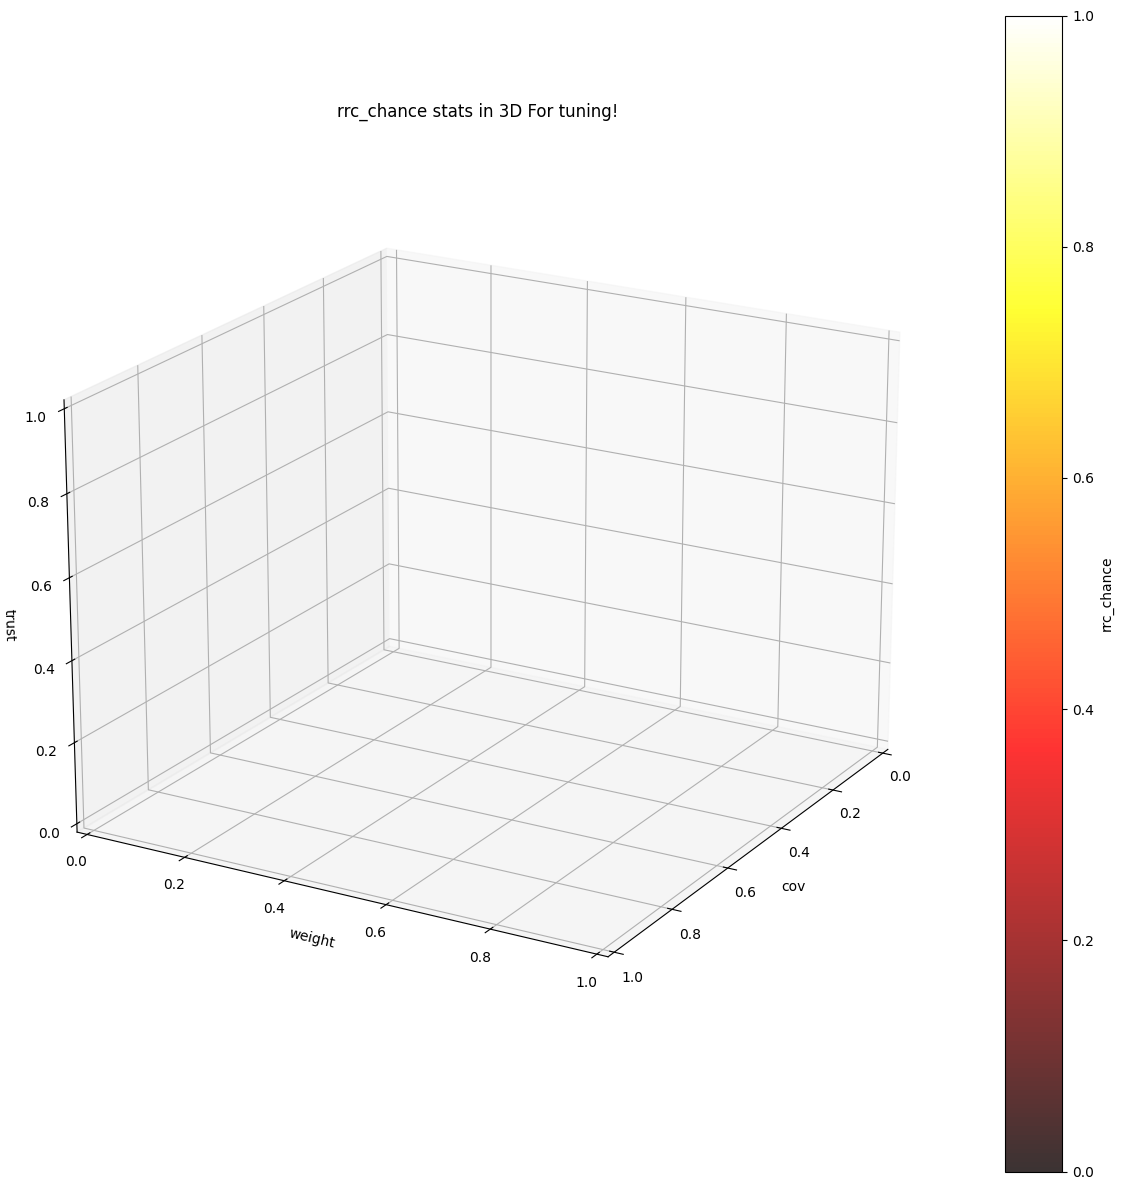

In [52]:
if O_tuning:
    df_tuning['rre_chance'].value_counts()
    df_tuning['rrc_chance'].value_counts()
    heatmap_tuning_stats_3d(df_tuning,color_column='rrc_chance',color_column_min=0.1,color_column_max=0.01)
   




filtering rre_chance >= 0.0
num of rows before filtering: 95
rre_chance min: 0.0
num of rows after filtering: 95
filtering rre_chance <= 0.001
num of rows before filtering: 95
rre_chance max: 0.0
num of rows after filtering: 85


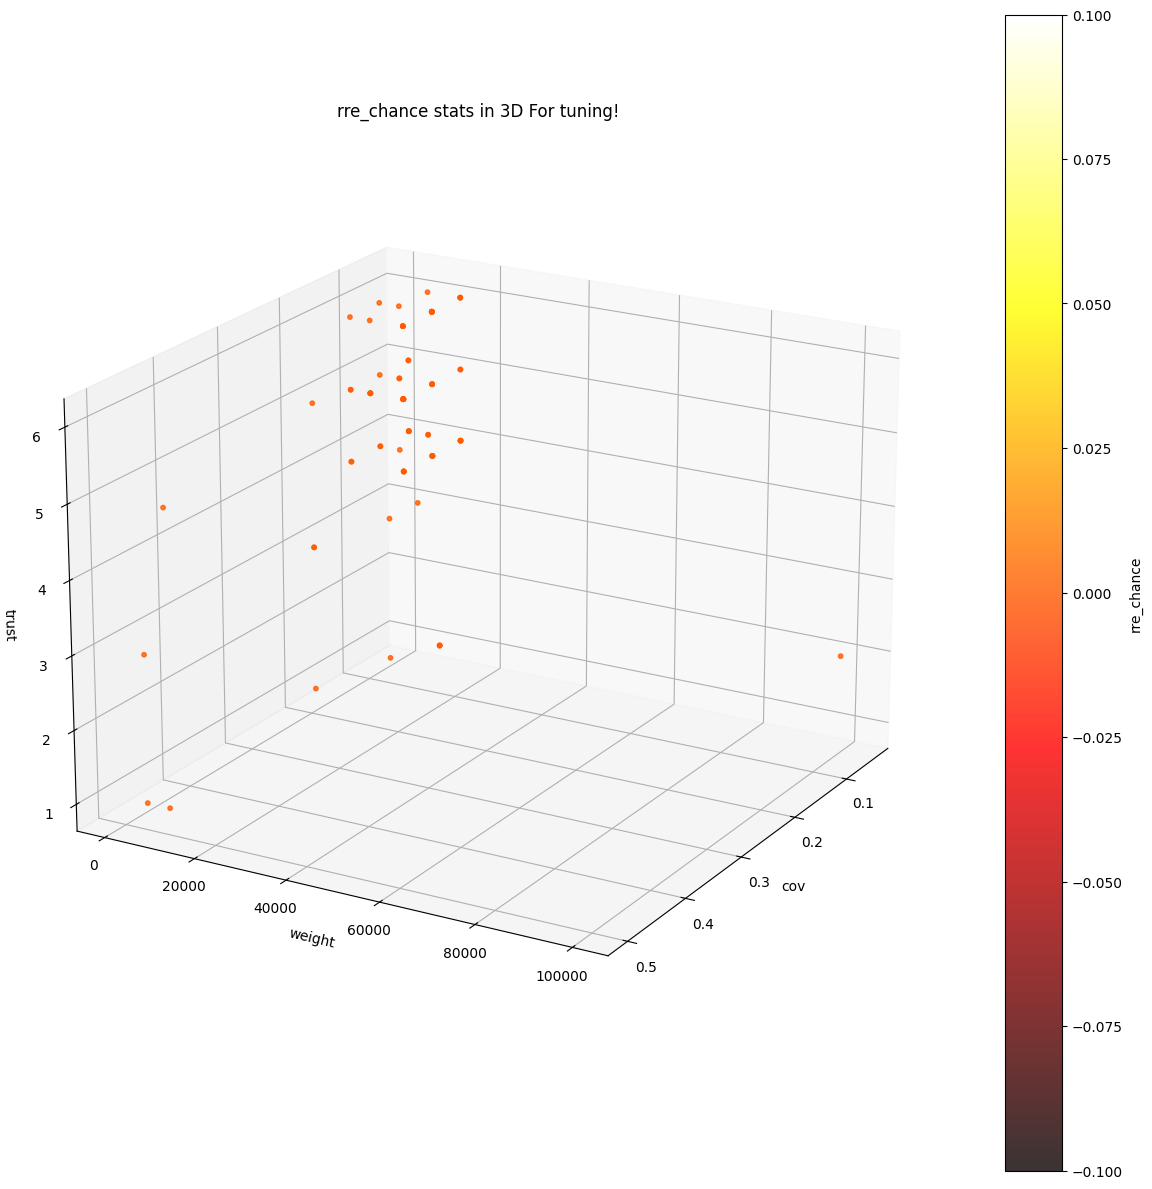

In [53]:
heatmap_tuning_stats_3d(df_tuning,color_column='rre_chance',color_column_min=0.0,color_column_max=0.001)


In [54]:
df_tun_zero_col = df_tuning[(df_tuning['rrc_chance'] == 0.0) & (df_tuning['rre_chance'] == 0.0)]

In [55]:

df_tuning_reach

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,sim_id,weight,trust,cov,changed_total,reached_total
0,O,4,500,reach,3,148,217,0.434,0.296,3,2025-08-24_11:03:30,15000,6,0.05,28.0,22.0
1,O,4,500,reach,1,0,0,0.000,0.000,0,2025-08-23_23:53:59,15000,4,0.10,45.0,44.0
2,O,4,500,reach,2,0,0,0.000,0.000,2,2025-08-24_06:03:53,15000,6,0.15,36.0,36.0
3,O,4,500,reach,1,0,0,0.000,0.000,0,2025-08-23_22:36:27,15000,5,0.15,40.0,40.0
4,O,4,500,reach,2,0,0,0.000,0.000,2,2025-08-24_03:49:43,3000,6,0.10,36.0,36.0
5,O,4,500,reach,3,63,0,0.000,0.126,4,2025-08-24_09:57:05,15000,6,0.15,34.0,29.0
6,O,4,500,reach,1,0,0,0.000,0.000,2,2025-08-23_23:57:18,15000,4,0.15,41.0,40.0
7,O,4,500,reach,3,60,98,0.196,0.120,0,2025-08-24_06:32:07,15000,5,0.15,34.0,29.0
8,O,4,500,reach,3,0,0,0.000,0.000,1,2025-08-24_08:15:01,15000,6,0.10,41.0,39.0
9,O,4,500,reach,3,44,0,0.000,0.088,4,2025-08-24_11:33:49,15000,5,0.10,43.0,42.0


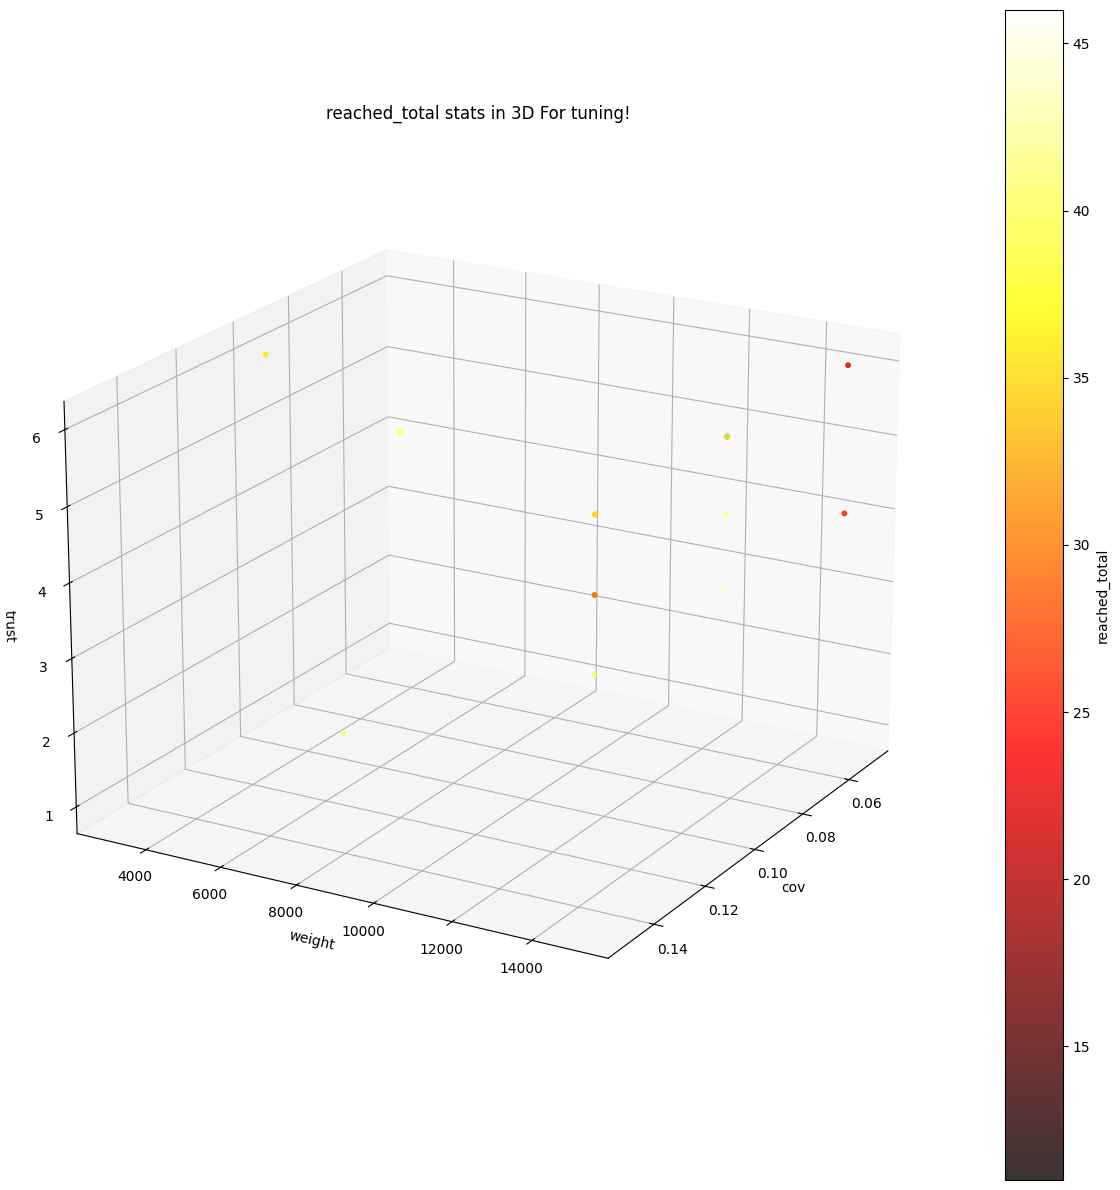

In [56]:
heatmap_tuning_stats_3d(df_tuning_reach,color_column='reached_total')


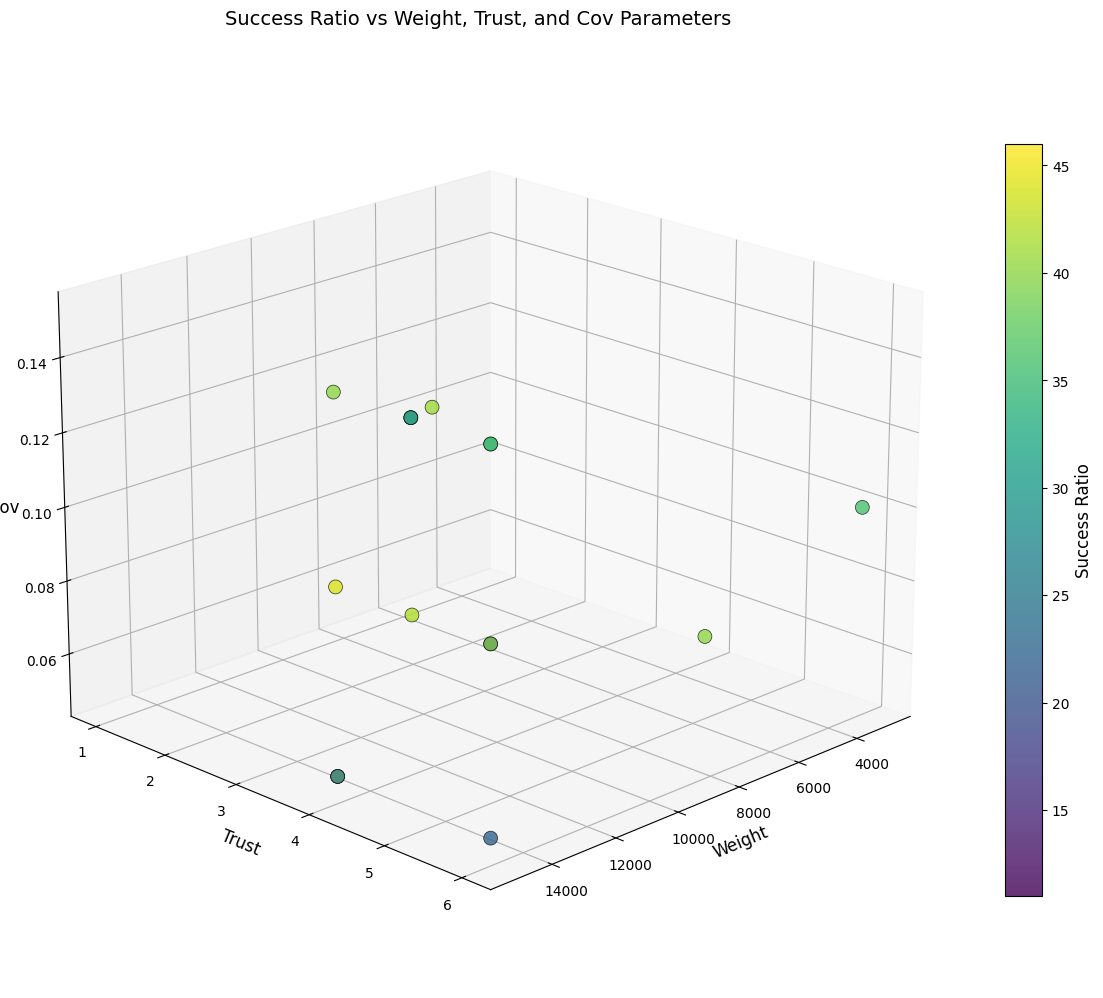

In [57]:
def plot_reached_total_3d(df_tuning):
    """
    Create a 3D scatter plot showing success count across weight, trust, and cov parameters
    """
    # Filter out any rows with NaN values
    df_clean = df_tuning.dropna(subset=['weight', 'trust', 'cov','reached_total'])
    
    # Create the 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d', elev=20, azim=45)
    
    # Create scatter plot with success_ratio as color
    scatter = ax.scatter(
        df_clean['weight'], 
        df_clean['trust'], 
        df_clean['cov'], 
        c=df_clean['reached_total'], 
        cmap='viridis',  # You can change this colormap (e.g., 'plasma', 'coolwarm', 'RdYlGn')
        marker='o', 
        edgecolor='black', 
        linewidth=0.5, 
        alpha=0.8, 
        s=100
    )
    
    # Set labels
    ax.set_xlabel('Weight', fontsize=12)
    ax.set_ylabel('Trust', fontsize=12)
    ax.set_zlabel('Cov', fontsize=12)
    
    # Set title
    plt.title('Success Ratio vs Weight, Trust, and Cov Parameters', fontsize=14, pad=20)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, aspect=20)
    cbar.set_label('Success Ratio', fontsize=12)
    
    # Customize the view
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_reached_total_3d(df_tuning_reach)

In [58]:
df_tuning_reach.describe()

,n_arms,wstep_total,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,weight,trust,cov,changed_total,reached_total
count,17.0,17.0,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.00000,17.000000
mean,4.0,500.0,2.352941,25.941176,24.294118,0.048588,0.051882,1.764706,13000.000000,4.764706,0.102941,37.00000,34.235294
std,0.0,0.0,0.931476,41.776893,59.299836,0.118600,0.083554,1.437420,4472.135955,1.300452,0.041347,6.47109,9.107205
min,4.0,500.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3000.000000,1.000000,0.050000,22.00000,11.000000
25%,4.0,500.0,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15000.000000,4.000000,0.050000,34.00000,29.000000
50%,4.0,500.0,3.000000,0.000000,0.000000,0.000000,0.000000,2.000000,15000.000000,5.000000,0.100000,36.00000,36.000000
75%,4.0,500.0,3.000000,60.000000,0.000000,0.000000,0.120000,3.000000,15000.000000,6.000000,0.150000,42.00000,40.000000
max,4.0,500.0,4.000000,148.000000,217.000000,0.434000,0.296000,4.000000,15000.000000,6.000000,0.150000,46.00000,46.000000


In [59]:
# If cov has only one value, let's use a different approach
if len(df_tuning_reach['cov'].unique()) == 1:
    print("\nCov has only one value, let's use a 2D plot instead or modify the approach")
    
    # Option 1: 2D scatter plot with weight vs trust, colored by reached total
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(
        df_tuning_reach['weight'], 
        df_tuning_reach['trust'], 
        c=df_tuning_reach['reached_total'], 
        cmap='viridis',
        s=100,
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5
    )
    
    ax.set_xlabel('Weight', fontsize=12)
    ax.set_ylabel('Trust', fontsize=12)
    ax.set_title('Success Ratio vs Weight and Trust (Cov = 0.1)', fontsize=14)
    
    cbar = plt.colorbar(scatter)
    cbar.set_label('Success Ratio', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Option 2: 3D plot but use a different variable for z-axis
    # For example, use task_level or another variable that has more variation
    if len(df_tuning_reach['task_level'].unique()) > 1:
        print("\nCreating 3D plot with task_level as z-axis instead of cov")
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d', elev=20, azim=45)
        
        scatter = ax.scatter(
            df_tuning_reach['weight'], 
            df_tuning_reach['trust'], 
            df_tuning_reach['task_level'], 
            c=df_tuning_reach['reached_total'], 
            cmap='viridis',
            marker='o', 
            edgecolor='black', 
            linewidth=0.5, 
            alpha=0.8, 
            s=100
        )
        
        ax.set_xlabel('Weight', fontsize=12)
        ax.set_ylabel('Trust', fontsize=12)
        ax.set_zlabel('Task Level', fontsize=12)
        ax.set_title('Success Ratio vs Weight, Trust, and Task Level', fontsize=14, pad=20)
        
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, aspect=20)
        cbar.set_label('Success Ratio', fontsize=12)
        
        plt.tight_layout()
        plt.show()

### Tuning: Normalized scores for each task (bin,reach,follow) and for safety (robot-robot-collisions, robot-env-collisions). For each metric: min:0 means worst, max: 1 means best.

#### Task scores:
- bin: total number of placed objects out of max number of placed objects achieved by the best candidate. 
- reach: total num of reached objects / max total num of eached objects by any simulation
- follow: First we normalize mean pos error over time to range of 0-1,(so 0 means best, 1 means worst). Then we invert it so 0 means worst, 1 means best.


#### Safety scores:
- safety_score_rrc : 1 - rrc, where rrc is chance of collision between robots (robot-robot-collision) in simulation (total t in col with robots / total t)
- safety_score_rec : 1 - rec, where rec  chance of collision between robots end environment (robot-env-col) (total t in col with robots / total t)



All configs sored by the mean task score over all tasks (1 means perfect score in all tasks, 0 means failure in all tasks)
top 10 configs by task score
cfg(weight,trust,cov), max p(col)robot-robot, max p(col)robot-env, Reach sims, Bin sims, Follow sims
((np.int64(15000), np.int64(5), np.float64(0.1)), np.float64(0.7824196505686698), np.float64(0.0), np.float64(0.0), 0, 1, 3)
cfg(weight,trust,cov), max p(col)robot-robot, max p(col)robot-env, Reach sims, Bin sims, Follow sims
((np.int64(15000), np.int64(6), np.float64(0.05)), np.float64(0.7583649083895134), np.float64(0.0), np.float64(0.0), 0, 1, 1)
cfg(weight,trust,cov), max p(col)robot-robot, max p(col)robot-env, Reach sims, Bin sims, Follow sims
((np.int64(15000), np.int64(4), np.float64(0.1)), np.float64(0.6871740479858431), np.float64(0.0), np.float64(0.0), 1, 1, 3)
cfg(weight,trust,cov), max p(col)robot-robot, max p(col)robot-env, Reach sims, Bin sims, Follow sims
((np.int64(15000), np.int64(6), np.float64(0.1)), np.float64(0.64039

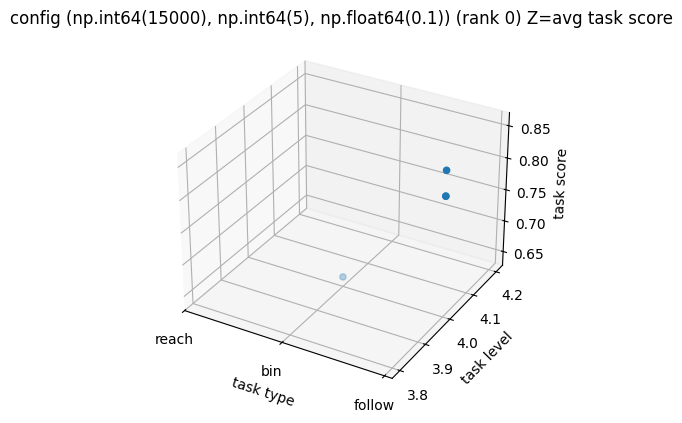

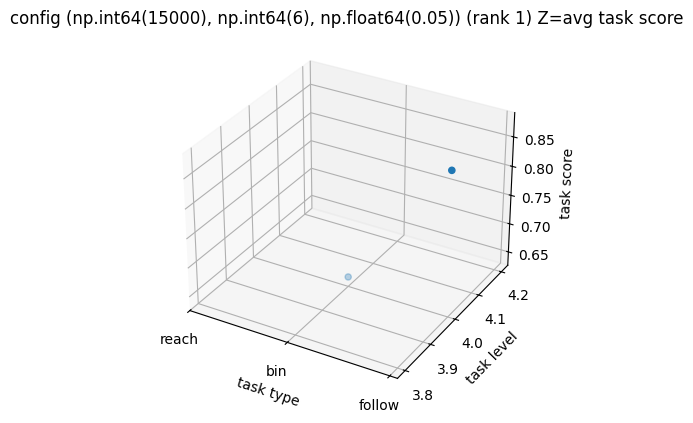

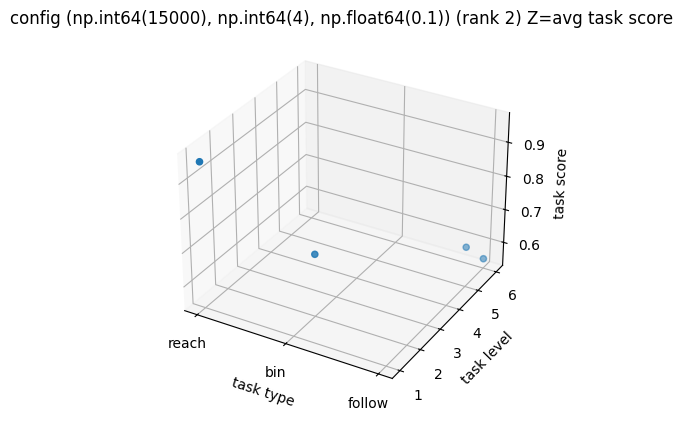

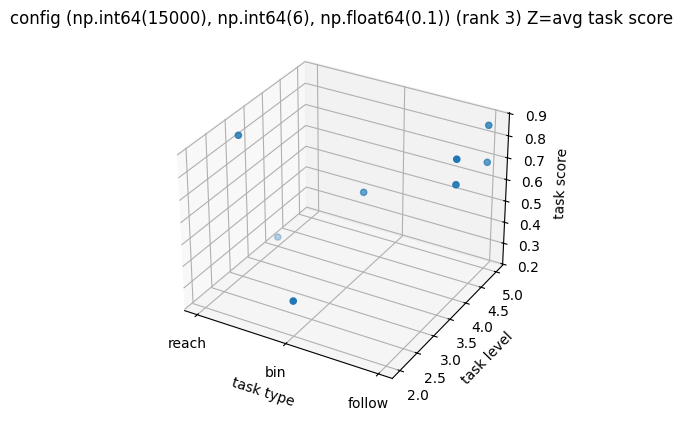

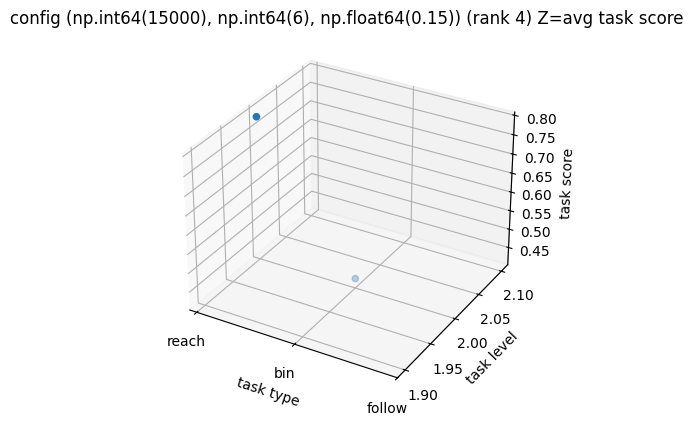

In [60]:

task_score_cols = ['task_score_reach','task_score_bin','task_score_follow']
safety_score_cols = ['rrc_chance','rre_chance']


df_tuning['task_score_reach'] = df_tuning['reached_total'] / df_tuning['reached_total'].max()
df_tuning['task_score_bin'] = df_tuning['placed_total']  / df_tuning['picked_total'].max()
df_tuning['task_score_follow'] = 1 - (df_tuning['p_err_mean_arms_wsteps'] - df_tuning['p_err_mean_arms_wsteps'].min()) / (df_tuning['p_err_mean_arms_wsteps'].max() - df_tuning['p_err_mean_arms_wsteps'].min()) 
df_tuning['safety_score_rrc'] = 1 - df_tuning['rrc_chance']
df_tuning['safety_score_rec'] = 1 - df_tuning['rre_chance']


df_tuning_colfree =  df_tuning.copy()
df_tuning_colfree = df_tuning_colfree[(df_tuning_colfree['rrc_chance'] == 0.0) & (df_tuning_colfree['rre_chance'] == 0.0)]
df_tuning_colfree[['task_score_reach','task_score_bin','task_score_follow']] = df_tuning_colfree[['task_score_reach','task_score_bin','task_score_follow']].fillna(0) 
df_tuning_colfree['task_score'] = df_tuning_colfree[['task_score_reach','task_score_bin','task_score_follow']].sum(axis=1)

df_tuning_colfree_gb_paramconfig = df_tuning_colfree.groupby(['weight','trust','cov'])

# df_tuning_colfree_gb_paramconfig['config_task_score'] = df_tuning_colfree_gb_paramconfig['task_score'].mean() # mean over all seeds, for each param config

tasks_to_focus = ['bin']
task_score_means_by_config = []

for g_name, g in df_tuning_colfree_gb_paramconfig:
    mean_task_score_config = g['task_score'].mean() # group name (describing a unique config)
    # mean_rrc_score_config = g['safety_score_rrc'].mean()
    # mean_rre_score_config = g['safety_score_rec'].mean()
    rrc_chance_config_max = g['rrc_chance'].max()
    rec_chance_config_max = g['rre_chance'].max()
    n_tasks_config = len(g)
    n_bin_tasks_config = len(g[g['task_type'] == 'bin'])
    if n_bin_tasks_config == 0 and 'bin' in tasks_to_focus:
        continue
    n_follow_tasks_config = len(g[g['task_type'] == 'follow'])
    if n_follow_tasks_config == 0 and 'follow' in tasks_to_focus:
        continue
    n_reach_tasks_config = len(g[g['task_type'] == 'reach'])
    if n_reach_tasks_config == 0 and 'reach' in tasks_to_focus:
        continue 


    # task_score_means_by_config.append((g_name,mean_task_score_config,mean_rrc_score_config,mean_rre_score_config))
    
    

    task_score_means_by_config.append((g_name,mean_task_score_config,rrc_chance_config_max,rec_chance_config_max,n_reach_tasks_config,n_bin_tasks_config,n_follow_tasks_config))
    


task_score_means_by_config.sort(key=lambda x: x[1], reverse=True)
# best_group_name = task_score_means_by_config[0][0]

k = 10 # k best configs by avg task score and 0 collisions
print ('All configs sored by the mean task score over all tasks (1 means perfect score in all tasks, 0 means failure in all tasks)')
print(f'top {k} configs by task score')
for i in range(k):
    print(f'cfg(weight,trust,cov), max p(col)robot-robot, max p(col)robot-env, Reach sims, Bin sims, Follow sims')
    print(task_score_means_by_config[i])


    
    

def plot_config_by_rank(rank=0):
    group_name_by_rank = task_score_means_by_config[rank][0]
    config_df = df_tuning_colfree_gb_paramconfig.get_group(group_name_by_rank)
    # some plots of 
    z = config_df['task_score']
    n = len(z)
    #x1_best_cfg_plots = config_df['task_type']
    y = config_df['task_level']
   
    task_type_to_int = {'reach': 0, 'bin': 1, 'follow': 2}
    x = [task_type_to_int[task_type] for task_type in config_df['task_type']]

    # make 3d plot of task score vs rrc chance vs rec chance
    fig = plt.figure()

    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z)
    ax.set_xlabel('task type')
    ax.set_ylabel('task level')
    ax.set_zlabel('task score')
    ax.set_xticks([0, 1, 2])
    # ax.set_yticks([0,1]) 
    ax.set_xticklabels(['reach', 'bin', 'follow'])
    ax.set_title(f'config {group_name_by_rank} (rank {rank}) Z=avg task score')
    plt.show()




for i in range(5):
    plot_config_by_rank(i)






In [61]:
def get_sim_ids_by_config(cfg:tuple):
    config_df = df_tuning_colfree_gb_paramconfig.get_group(cfg)
    sim_ids = config_df['sim_id'].unique()
    return sim_ids

best_cfg = task_score_means_by_config[0][0]
print(f'best cfg out dirs')
print(get_sim_ids_by_config(best_cfg))

print('second best cfg out dirs')
print(get_sim_ids_by_config(task_score_means_by_config[1][0]))

best cfg out dirs
['2025-08-23_02:21:12' '2025-08-23_10:50:22' '2025-08-23_11:38:52'
 '2025-08-23_11:16:07']
second best cfg out dirs
['2025-08-23_03:26:58' '2025-08-23_12:26:55']
